# Credit Card Fraud Detection — AIM ML Capstone
## Step 3: Data Preprocessing, Applied EDA & Feature Engineering

**Author:** Erickson Tan  
**Institution:** Asian Institute of Management  
**Dataset:** ULB Credit Card Fraud Detection (Kaggle)  
**Environment:** Google Colab (Python 3.x)

---

### About This Notebook

This notebook serves as the **EDA + Feature Engineering Report** deliverable for Step 3 of the AIM ML Capstone. It covers the complete data preparation pipeline from raw data loading through to resampled training datasets ready for modelling.

Each section includes both executable code and written justification for every decision made. The goal is not just to clean and transform the data, but to understand what the data is telling us before a single model is trained.

### Notebook Structure

| Section | Content |
|---|---|
| 1 | Setup & Data Loading |
| 2 | Data Cleaning (missing values, duplicates, outliers, scaling) |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Engineering |
| 5 | Feature Importance & SHAP Explainability |
| 6 | Feature Selection (three-method consensus) |
| 7 | Dimensionality Reduction (PCA + t-SNE) |
| 8 | Imbalance Handling (SMOTE + Undersampling + Combined) |

**Output:** Cleaned dataset, 15 selected features, and three resampled training sets passed to Step 4.  



## Section 1: Setup & Data Loading

We begin by installing the two libraries not pre-installed in Google Colab `imbalanced-learn` for resampling techniques (SMOTE and undersampling) and `shap` for model explainability. All other libraries used throughout this notebook are part of the standard Colab environment.


In [1]:
#Cell 1

!pip install imbalanced-learn shap -q

#reason: imblanced-learn gives us SMOTE and undersampling because the target data is heavily imbalanced
#shap gives explainability

In [2]:
#Cell 2

# Core libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
from datetime import datetime, timedelta

# Visualisation Libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Preprocessing Libraries
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Feature Selection Libraries
from sklearn.feature_selection import SelectKBest, f_classif, mutual_info_classif
from sklearn.linear_model import LassoCV

# Imbalance Handling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

# Explainability Libraries
import shap

# Utilities Libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier, IsolationForest

# Other Scikit-learn imports
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, OneClassSVM
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    silhouette_score, davies_bouldin_score, mean_squared_error, r2_score
)
from sklearn.utils.class_weight import compute_class_weight

### Loading the Dataset

The dataset is loaded directly from the `/content/` folder.




The dataset is included with this submission.  
Original source: [Kaggle — ULB Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)


In [3]:
#Cell 3

from google.colab import files
uploaded = files.upload()
# Select creditcard.csv when the button appears

Saving creditcard.csv to creditcard.csv


In [4]:
#Cell 4

#Verify the correct file is loaded

import os

file_path = '/content/creditcard.csv'
size_mb = os.path.getsize(file_path) / 1e6

print(f"File size: {size_mb:.1f} MB")
print(f"Expected : ~144.0 MB")

if size_mb > 140:
    df = pd.read_csv(file_path)
    print(f"\n✅ Correct file loaded")
    print(f"   Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
    print(f"   Expected: 284,807 rows x 31 columns")
else:
    print(f"\n❌ Wrong file — too small ({size_mb:.1f}MB)")
    print(f"   Please download the full dataset from Kaggle again")

File size: 150.8 MB
Expected : ~144.0 MB

✅ Correct file loaded
   Shape: 284,807 rows x 31 columns
   Expected: 284,807 rows x 31 columns


### Initial Dataset Overview

Before any cleaning or transformation, we examine the raw structure of the dataset, the shape, data types, basic statistics, and class distribution. This establishes our baseline understanding and documents the starting point before any modifications are made.

It is worth noting that the V1–V28 features are the result of PCA applied by ULB researchers to protect cardholder privacy. Their individual descriptive statistics (mean, standard deviation, min/max) do not carry direct business interpretation. PCA components are mathematical abstractions of the original transaction features. What matters is not what each component means individually, but the patterns they encode collectively as inputs to a predictive model.


In [5]:
#Cell 5

#Data shape and types

print("=" * 50)
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
print("=" * 50)
print(f"Data types:\n{df.dtypes}")
print(df.dtypes.value_counts())


#Basic Statistics
print("=" * 50)
print("\nDescriptive Statistics (Amount & Time):") #only these 3 features, because V1...V28 are PCA features
display(df[['Time', 'Amount', 'Class']].describe().round(2))

#Check if there are missing values
print("=" * 50)
print(f'Missing Values Count: {df.isnull().sum()}')

#Count distribution
print("=" * 50)
fraud_count = df['Class'].sum()
legit_count = len(df) - fraud_count
fraud_pct = fraud_count / len(df) * 100

print("\nClass Distribution:")
print(f"Legitimate: {legit_count:,} ({100 - fraud_pct:.3f}%)")
print(f"Fraudulent: {fraud_count:,} ({fraud_pct:.3f}%)")
print(f'Ratio: {legit_count // fraud_count}:1')
#

Shape: 284,807 rows x 31 columns
Data types:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object
float64    30
int64       1
Name: count, dtype: int64

Descriptive Statistics (Amount & Time):


,Time,Amount,Class
count,284807.00,284807.00,284807.00
mean,94813.86,88.35,0.00
std,47488.15,250.12,0.04
min,0.00,0.00,0.00
25%,54201.50,5.60,0.00
50%,84692.00,22.00,0.00
75%,139320.50,77.16,0.00
max,172792.00,25691.16,1.00


Missing Values Count: Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Class Distribution:
Legitimate: 284,315 (99.827%)
Fraudulent: 492 (0.173%)
Ratio: 577:1


### Note on PCA Feature Statistics

The descriptive statistics for V1–V28 will show values clustered around zero with varying spreads. This is the expected signature of PCA-transformed data. Unlike `Time` and `Amount`, which have interpretable units (seconds and EUR respectively), the V features have no direct real-world units. This is by design: PCA abstracts the original transaction details into orthogonal components that preserve statistical variance while protecting individual cardholder identity.

For modelling purposes, what matters is that these components carry sufficient signal to distinguish fraud from legitimate transactions, something we will confirm through SHAP analysis in Section 5.


---
## Section 2: Data Cleaning

Before any analysis or modelling, we ensure the dataset is free of issues that could distort results or introduce bias. Our cleaning process covers three tasks:

1. **Missing value check** — confirm no nulls exist across all 31 columns
2. **Duplicate removal** — detect and remove exact duplicate rows
3. **Outlier review + feature scaling** — review extreme values in `Amount` and apply appropriate scaling to `Time` and `Amount`

Since the ULB dataset is documented as having no missing values, our primary cleaning concern is duplicate rows and the scale disparity between features.


### 2.1 Missing Value Analysis

We systematically check every column for missing values. This is a required baseline step even when the dataset is documented as complete — it confirms the integrity of the file we received and provides an auditable record for the submission.


In [6]:
#Cell 6

print("=" * 50)
print("MISSING VALUE ANALYSIS")
print("=" * 50)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count' : missing,
    'Missing %'     : missing_pct.round(4)
})

# Only show columns that have missing values
missing_found = missing_df[missing_df['Missing Count'] > 0]

if len(missing_found) == 0:
    print(f"\n✅ No missing values found across all {df.shape[1]} columns.")
    print(f"   Total cells checked: {df.shape[0] * df.shape[1]:,}")
else:
    print(f"\n⚠️  Missing values detected:")
    display(missing_found)

# Show full summary regardless
print(f"\n📋 Full Missing Value Summary:")
display(missing_df)

MISSING VALUE ANALYSIS

✅ No missing values found across all 31 columns.
   Total cells checked: 8,829,017

📋 Full Missing Value Summary:


,Missing Count,Missing %
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0


### 2.2 Duplicate Row Detection & Removal

A row is considered a duplicate if all values across every column are identical to another row in the dataset. In pandas, `df.duplicated()` checks each row against all preceding rows and marks it `True` on a match.

Duplicate rows are problematic for machine learning because they create artificial frequency bias the model sees certain transaction patterns more often than they actually occur, which can distort learned decision boundaries. We keep the first occurrence of each duplicate and remove all subsequent copies.


In [7]:
#Cell 7

print("=" *50)
print('Data Cleaning - Duplicates')
print("=" *50)

dupes = df.duplicated().sum()
print(f'\nDuplicate row found: {dupes:,}')
print(f'Rows before cleaning: {len(df):,}')

Data Cleaning - Duplicates

Duplicate row found: 1,081
Rows before cleaning: 284,807


In [8]:
#Cell 8

print("=" *50)
print('Data Cleaning - Remove Duplicates')
print("=" *50)

df = df.drop_duplicates()
df = df.reset_index(drop=True)  #reset the index of the dataframe after dropping duplicates to avoid error in index position
print(f'Rows after cleaning: {len(df):,}')
print(f'Rows removed: {dupes:,}')
print(f"\nDuplicate removed completed")

Data Cleaning - Remove Duplicates
Rows after cleaning: 283,726
Rows removed: 1,081

Duplicate removed completed


> **Decision:** Duplicate rows are dropped and the index is reset. The first occurrence is retained on the assumption that it represents the original transaction record. Any downstream changes to row counts or fraud ratios reflect this cleaning step.


### 2.3 Outlier Review — Amount Feature

We use the IQR (Interquartile Range) method to identify mild and extreme outliers in the `Amount` feature. The upper fence is set at Q3 + 1.5×IQR (mild) and Q3 + 3.0×IQR (extreme).

**Important decision:** Outliers in `Amount` are NOT removed. High-value transactions are legitimate business events, a large purchase at a luxury retailer is not an error. Removing them would destroy real signal and distort the model's understanding of normal high-value behaviour. Instead, we handle their influence through feature scaling in the next step.

We also examine how many fraud cases fall within the outlier ranges, as this informs whether high-value transactions are disproportionately associated with fraud.


In [9]:
#Cell 9

print("=" *50)
print('Data Cleaning - Outlier Review (Feature: Amount)')
print("=" *50)

Q1 = df['Amount'].quantile(0.25)
Q3 = df['Amount'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + (1.5 * IQR)
extreme_fence = Q3 + (3.0 * IQR)

outliers_mild = df[df['Amount'] > upper_fence]
outliers_extreme = df[df['Amount'] > extreme_fence]

print(f"\nQ1                  : €{Q1:.2f}")
print(f"Q3                  : €{Q3:.2f}")
print(f"IQR                 : €{IQR:.2f}")
print(f"Upper fence (1.5×)  : €{upper_fence:.2f}")
print(f"Extreme fence (3×)  : €{extreme_fence:.2f}")
print(f"\nMild outliers       : {len(outliers_mild):,} rows")
print(f"Extreme outliers    : {len(outliers_extreme):,} rows")
print(f"\nFraud among mild outliers    : {outliers_mild['Class'].sum()}")
print(f"Fraud among extreme outliers : {outliers_extreme['Class'].sum()}")
print(f"\n⚠️  Note: Outliers are NOT removed.")
print(f"   High-value transactions are legitimate business events.")
print(f"   RobustScaler in the next cell will handle their influence.")

Data Cleaning - Outlier Review (Feature: Amount)

Q1                  : €5.60
Q3                  : €77.51
IQR                 : €71.91
Upper fence (1.5×)  : €185.38
Extreme fence (3×)  : €293.24

Mild outliers       : 31,685 rows
Extreme outliers    : 18,802 rows

Fraud among mild outliers    : 87
Fraud among extreme outliers : 63

⚠️  Note: Outliers are NOT removed.
   High-value transactions are legitimate business events.
   RobustScaler in the next cell will handle their influence.


### 2.4 Feature Scaling — Scaler Comparison

The `Time` and `Amount` features require scaling before modelling. The V1–V28 features are already standardised (mean ≈ 0, unit variance) as a byproduct of PCA, they do not need further scaling.

We compare three scaling approaches on both features to justify our selection:

| Scaler | Method | Sensitivity to Outliers |
|---|---|---|
| StandardScaler | (x − mean) / std | High — mean and std pulled by extreme values |
| MinMaxScaler | (x − min) / (max − min) | Very high — single extreme value dominates the range |
| RobustScaler | (x − median) / IQR | Low — uses median and IQR, resistant to outliers |

The boxplot comparison below visualises the effect of each scaler on both features.


FEATURE SCALING — Time & Amount


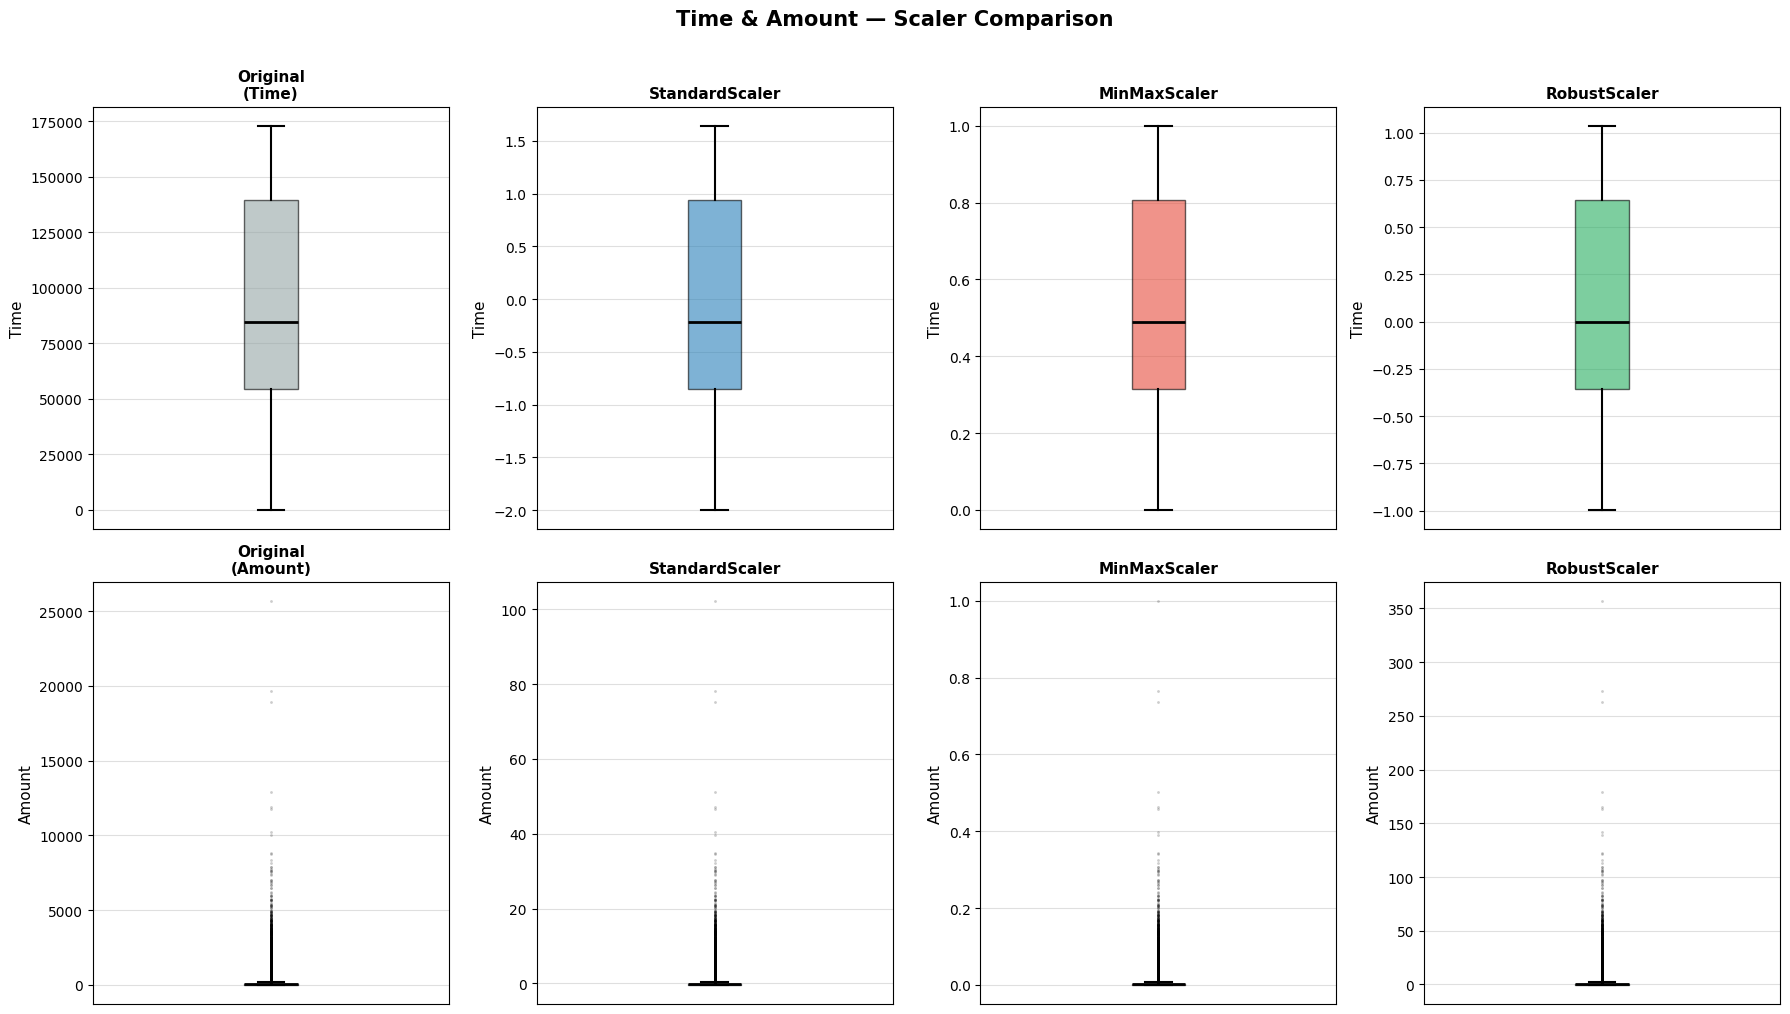


📋 Original Feature Stats:

            Time     Amount
count  283726.00  283726.00
mean    94811.08      88.47
std     47481.05     250.40
min         0.00       0.00
25%     54204.75       5.60
50%     84692.50      22.00
75%    139298.00      77.51
max    172792.00   25691.16


In [10]:
#Cell 10

print("=" * 50)
print("FEATURE SCALING — Time & Amount")
print("=" * 50)

#V1 to V28 does not need scaling because it was already scaled in performing PCA
#Class does not need scaling since the target is already has a binary values

features = ['Time', 'Amount']

scaler_dict = {
    'Original'       : None,
    'StandardScaler' : StandardScaler(),
    'MinMaxScaler'   : MinMaxScaler(),
    'RobustScaler'   : RobustScaler(),
}

colors = ['#95a5a6', '#2980b9', '#e74c3c', '#27ae60']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))

for row, feature in enumerate(features):
    values = df[feature].values.reshape(-1, 1)

    for col, (scaler_name, scaler) in enumerate(scaler_dict.items()):
        if scaler is None:
            scaled = values
            title = f'Original\n({feature})'
        else:
            scaled = scaler.fit_transform(values)
            title = scaler_name

        axes[row, col].boxplot(
            scaled,
            patch_artist=True,
            boxprops=dict(facecolor=colors[col], alpha=0.6),
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='.', color=colors[col], alpha=0.2, markersize=2),
            whiskerprops=dict(linewidth=1.5),
            capprops=dict(linewidth=1.5)
        )

        axes[row, col].set_title(title, fontsize=11, fontweight='bold')
        axes[row, col].set_xticks([])
        axes[row, col].set_ylabel(feature, fontsize=11)
        axes[row, col].grid(axis='y', alpha=0.4)

fig.suptitle('Time & Amount — Scaler Comparison', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('scaler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary Stats ──────────────────────────────────
print("\n📋 Original Feature Stats:\n")
print(df[['Time', 'Amount']].describe().round(2).to_string())



In [11]:
#Cell 11

# ── Scaler Decision ────────────────────────────────
print("=" * 50)
print("SCALER SELECTION DECISION")
print("=" * 50)

print("""
Observations from the boxplot comparison:

  Original        — Heavily right-skewed. Extreme outliers up to €25,691
                    dominate the scale, compressing the bulk of data.

  StandardScaler  — Reduces scale but outliers still exert strong pull
                    on the mean and std, distorting the transformation.

  MinMaxScaler    — Compresses all values into [0, 1] but is the most
                    sensitive to outliers — a single extreme value
                    pushes everything else toward zero.

  RobustScaler    — Uses median and IQR instead of mean and std.
                    Outliers have minimal influence. The bulk of
                    transactions are well-spread around zero.

Decision: RobustScaler selected for Time and Amount.
Reason  : Amount is heavily right-skewed with extreme outliers that
          represent legitimate high-value transactions not errors.
          RobustScaler handles this without distorting the distribution
          or requiring outlier removal.
""")

SCALER SELECTION DECISION

Observations from the boxplot comparison:

  Original        — Heavily right-skewed. Extreme outliers up to €25,691
                    dominate the scale, compressing the bulk of data.

  StandardScaler  — Reduces scale but outliers still exert strong pull
                    on the mean and std, distorting the transformation.

  MinMaxScaler    — Compresses all values into [0, 1] but is the most
                    sensitive to outliers — a single extreme value
                    pushes everything else toward zero.

  RobustScaler    — Uses median and IQR instead of mean and std.
                    Outliers have minimal influence. The bulk of
                    transactions are well-spread around zero.

Decision: RobustScaler selected for Time and Amount.
Reason  : Amount is heavily right-skewed with extreme outliers that
          represent legitimate high-value transactions not errors.
          RobustScaler handles this without distorting the distribu

### Scaler Decision

> **Selected: RobustScaler for both `Time` and `Amount`**

While all three scalers produce visually similar boxplot shapes for `Amount` (due to its inherent right skew), the mathematical justification for RobustScaler is clear: it uses the **median and IQR** instead of the mean and standard deviation, making it resistant to the extreme high-value transactions that we deliberately chose not to remove. For `Time`, RobustScaler produces the most symmetric box centred at zero, consistent with the distribution of the V1–V28 features it will be used alongside.

A key indicator that RobustScaler is working correctly: after scaling, the **median of both features is 0.000**, while the mean is non-zero (due to the remaining right skew). This median-zero centring is the defining signature of RobustScaler.


In [12]:
#Cell 12


# Apply RobustScaler to Time & Amount
print("=" * 50)
print("APPLYING ROBUSTSCALER — Time & Amount")
print("=" * 50)

robust = RobustScaler()

# Scale both features and add as new columns
df['Time_scaled']   = robust.fit_transform(df[['Time']])
df['Amount_scaled'] = robust.fit_transform(df[['Amount']])

# Drop original unscaled columns
df = df.drop(columns=['Time', 'Amount']) #these makes all the features are scaled

# Verify
print(f"\nNew columns added    : Time_scaled, Amount_scaled")
print(f"Columns dropped      : Time, Amount")
print(f"\nTime_scaled stats:")
print(f"  Mean   : {df['Time_scaled'].mean():.4f}")
print(f"  Median : {df['Time_scaled'].median():.4f}")
print(f"  Std    : {df['Time_scaled'].std():.4f}")
print(f"\nAmount_scaled stats:")
print(f"  Mean   : {df['Amount_scaled'].mean():.4f}")
print(f"  Median : {df['Amount_scaled'].median():.4f}")
print(f"  Std    : {df['Amount_scaled'].std():.4f}")
print(f"\nFinal cleaned shape  : {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n✅ Scaling complete. Dataset ready for EDA.")

APPLYING ROBUSTSCALER — Time & Amount

New columns added    : Time_scaled, Amount_scaled
Columns dropped      : Time, Amount

Time_scaled stats:
  Mean   : 0.1189
  Median : 0.0000
  Std    : 0.5580

Amount_scaled stats:
  Mean   : 0.9244
  Median : 0.0000
  Std    : 3.4821

Final cleaned shape  : 283,726 rows × 31 columns

✅ Scaling complete. Dataset ready for EDA.


In [13]:
#Cell 13

# Final Column Audit
print("=" * 50)
print("FINAL CLEANED DATASET — COLUMN AUDIT")
print("=" * 50)

print(f"\nTotal columns : {df.shape[1]}")
print(f"Total rows    : {df.shape[0]:,}")
print(f"\nColumn list:")

for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    nulls = df[col].isnull().sum()
    print(f"  {i:>2}. {col:<20} dtype: {dtype}    nulls: {nulls}")

print(f"\n✅ All columns confirmed. Proceeding to EDA.")

FINAL CLEANED DATASET — COLUMN AUDIT

Total columns : 31
Total rows    : 283,726

Column list:
   1. V1                   dtype: float64    nulls: 0
   2. V2                   dtype: float64    nulls: 0
   3. V3                   dtype: float64    nulls: 0
   4. V4                   dtype: float64    nulls: 0
   5. V5                   dtype: float64    nulls: 0
   6. V6                   dtype: float64    nulls: 0
   7. V7                   dtype: float64    nulls: 0
   8. V8                   dtype: float64    nulls: 0
   9. V9                   dtype: float64    nulls: 0
  10. V10                  dtype: float64    nulls: 0
  11. V11                  dtype: float64    nulls: 0
  12. V12                  dtype: float64    nulls: 0
  13. V13                  dtype: float64    nulls: 0
  14. V14                  dtype: float64    nulls: 0
  15. V15                  dtype: float64    nulls: 0
  16. V16                  dtype: float64    nulls: 0
  17. V17                  dtype: float64

---
## Section 3: Exploratory Data Analysis (EDA)

With a clean, scaled dataset, we now explore the data visually to build intuition before modelling. The EDA has four objectives:

1. **Quantify the class imbalance** and understand its implications for metric selection
2. **Compare feature distributions** between fraud and legitimate transactions
3. **Identify which features carry the most discriminatory signal** through correlation analysis
4. **Examine top fraud-signal features** in detail to understand how fraud manifests in the data

All charts in this section use the cleaned dataset after duplicate removal and scaling.


EDA 1: CLASS DISTRIBUTION


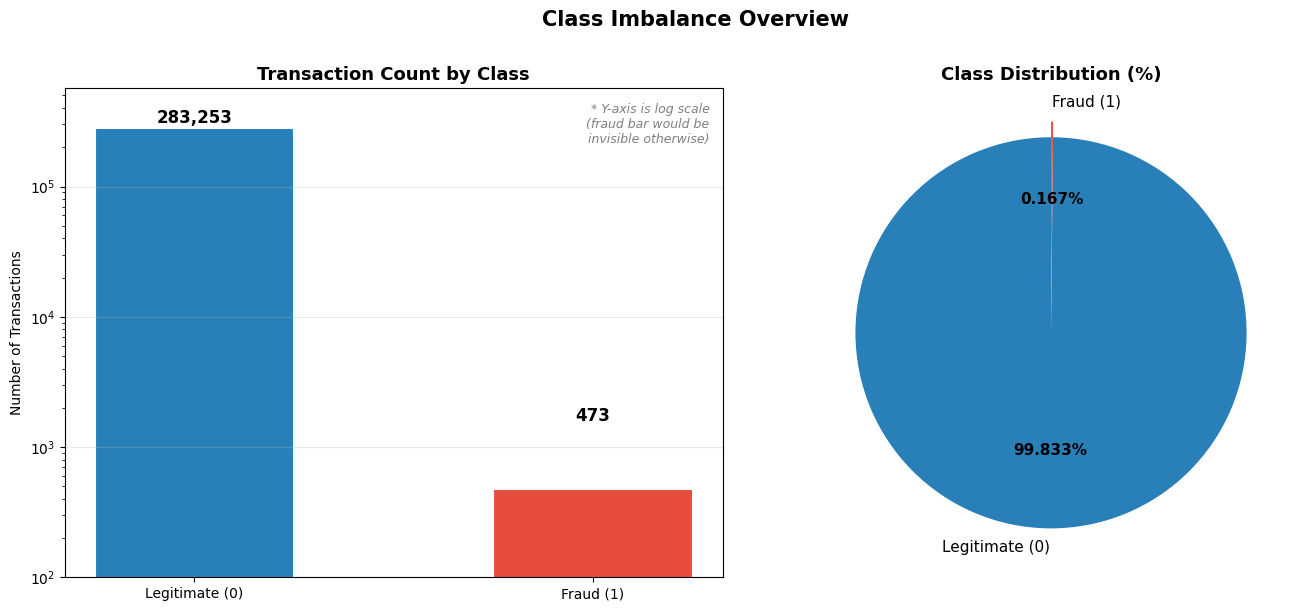


  Legitimate transactions : 283,253  (99.833%)
  Fraudulent transactions : 473  (0.167%)
  Imbalance ratio         : 598:1

  ⚠️  Severe imbalance confirmed.
  Standard accuracy is NOT a valid metric for this dataset.
  Primary metrics: AUC-ROC, F1-Score, Precision-Recall AUC.


In [14]:
#Cell 14

# ── Class Distribution ─────────────────────────────
print("=" * 50)
print("EDA 1: CLASS DISTRIBUTION")
print("=" * 50)

class_counts = df['Class'].value_counts()
class_labels = ['Legitimate (0)', 'Fraud (1)']
class_colors = ['#2980b9', '#e74c3c']

fraud_count = class_counts[1]
legit_count = class_counts[0]
total       = len(df)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Bar Chart ──────────────────────────────────────
bars = axes[0].bar(class_labels, class_counts.values,
                   color=class_colors, edgecolor='white',
                   linewidth=1.5, width=0.5)

for bar, count in zip(bars, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 1000,
                 f'{count:,}', ha='center', va='bottom',
                 fontweight='bold', fontsize=12)

axes[0].set_title('Transaction Count by Class', fontweight='bold', fontsize=13)
axes[0].set_ylabel('Number of Transactions')
axes[0].set_yscale('log')  # log scale so fraud bar is visible
axes[0].set_ylim(100, total * 2)
axes[0].grid(axis='y', alpha=0.3)
axes[0].annotate('* Y-axis is log scale\n  (fraud bar would be\n  invisible otherwise)',
                 xy=(0.98, 0.97), xycoords='axes fraction',
                 ha='right', va='top', fontsize=9,
                 color='gray', style='italic')

# ── Pie Chart ──────────────────────────────────────
pie_values  = [legit_count, fraud_count]
pie_explode = [0, 0.08]

wedges, texts, autotexts = axes[1].pie(
    pie_values,
    labels=class_labels,
    colors=class_colors,
    explode=pie_explode,
    autopct='%1.3f%%',
    startangle=90,
    textprops={'fontsize': 11}
)

for autotext in autotexts:
    autotext.set_fontweight('bold')

axes[1].set_title('Class Distribution (%)', fontweight='bold', fontsize=13)

fig.suptitle('Class Imbalance Overview', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print Summary ──────────────────────────────────
print(f"\n  Legitimate transactions : {legit_count:,}  ({legit_count/total*100:.3f}%)")
print(f"  Fraudulent transactions : {fraud_count:,}  ({fraud_count/total*100:.3f}%)")
print(f"  Imbalance ratio         : {legit_count//fraud_count}:1")
print(f"\n  ⚠️  Severe imbalance confirmed.")
print(f"  Standard accuracy is NOT a valid metric for this dataset.")
print(f"  Primary metrics: AUC-ROC, F1-Score, Precision-Recall AUC.")

### 📝 Note on Fraud Count After Deduplication

The original ULB dataset contains 492 labelled fraud transactions. After removing 1,081 duplicate rows during cleaning, the fraud count reduced to **473** , meaning **19 fraud records were exact duplicates** and have been correctly excluded.

This is the expected outcome of rigorous data cleaning. The corrected figures (473 fraud / 283,726 total / 598:1 ratio) are used for all subsequent analysis and modelling. Standard accuracy remains an invalid primary metric a model predicting every transaction as legitimate would achieve 99.83% accuracy while detecting zero fraud.


EDA 2: AMOUNT DISTRIBUTION — Fraud vs Legitimate

  Legitimate — Median Amount : 0.0000
  Fraudulent — Median Amount : -0.1694

  Legitimate — Mean Amount   : 0.9236
  Fraudulent — Mean Amount   : 1.4167


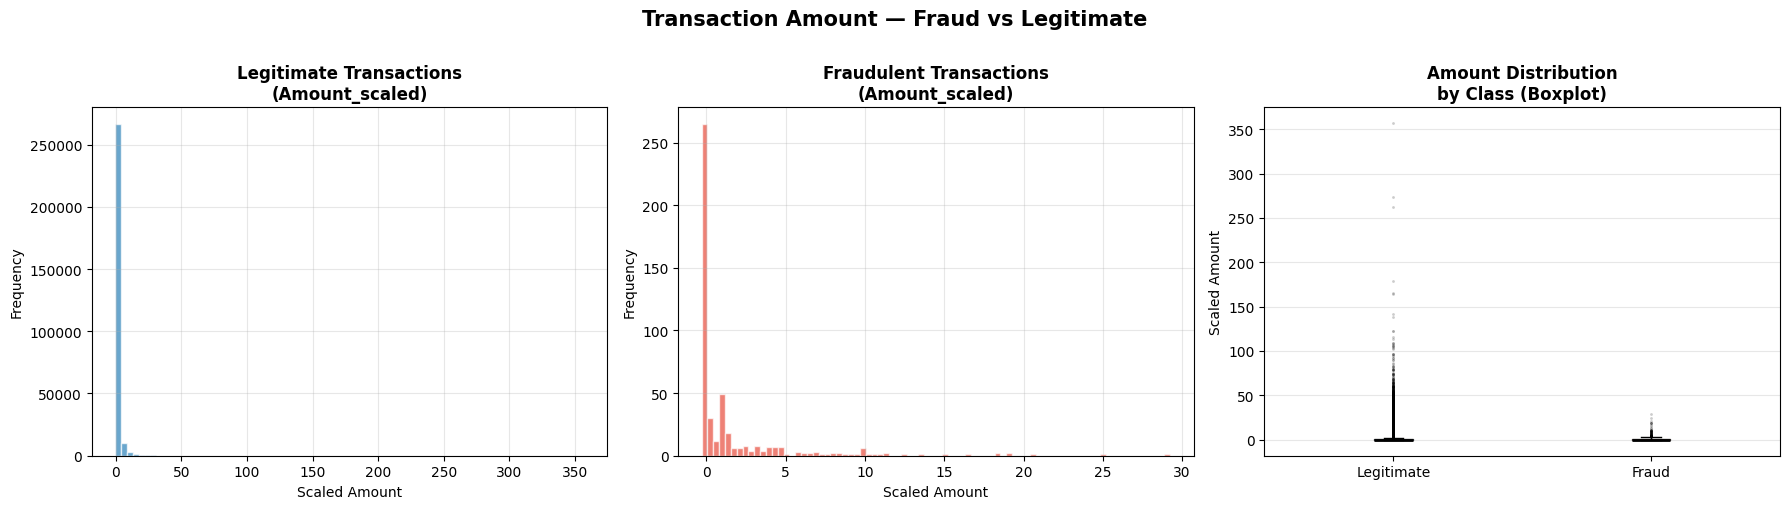

In [15]:
#Cell 15

# ── Amount Distribution by Class ───────────────────
print("=" * 50)
print("EDA 2: AMOUNT DISTRIBUTION — Fraud vs Legitimate")
print("=" * 50)

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Histogram: Legitimate ──────────────────────────
axes[0].hist(legit['Amount_scaled'], bins=80,
             color='#2980b9', alpha=0.7, edgecolor='white')
axes[0].set_title('Legitimate Transactions\n(Amount_scaled)', fontweight='bold')
axes[0].set_xlabel('Scaled Amount')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# ── Histogram: Fraud ───────────────────────────────
axes[1].hist(fraud['Amount_scaled'], bins=80,
             color='#e74c3c', alpha=0.7, edgecolor='white')
axes[1].set_title('Fraudulent Transactions\n(Amount_scaled)', fontweight='bold')
axes[1].set_xlabel('Scaled Amount')
axes[1].set_ylabel('Frequency')
axes[1].grid(alpha=0.3)

# ── Boxplot: Side by Side ──────────────────────────
axes[2].boxplot(
    [legit['Amount_scaled'], fraud['Amount_scaled']],
    labels=['Legitimate', 'Fraud'],
    patch_artist=True,
    boxprops=dict(alpha=0.7),
    medianprops=dict(color='black', linewidth=2),
    flierprops=dict(marker='.', alpha=0.2, markersize=2)
)
box_colors = ['#2980b9', '#e74c3c']
for patch, color in zip(axes[2].patches, box_colors):
    patch.set_facecolor(color)

axes[2].set_title('Amount Distribution\nby Class (Boxplot)', fontweight='bold')
axes[2].set_ylabel('Scaled Amount')
axes[2].grid(axis='y', alpha=0.3)

# ── Stats ──────────────────────────────────────────
print(f"\n  Legitimate — Median Amount : {legit['Amount_scaled'].median():.4f}")
print(f"  Fraudulent — Median Amount : {fraud['Amount_scaled'].median():.4f}")
print(f"\n  Legitimate — Mean Amount   : {legit['Amount_scaled'].mean():.4f}")
print(f"  Fraudulent — Mean Amount   : {fraud['Amount_scaled'].mean():.4f}")

fig.suptitle('Transaction Amount — Fraud vs Legitimate', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_02_amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA 2: Key Insight — Amount Distribution

The Amount distribution reveals a nuanced pattern: **fraud transactions have a lower median but higher mean than legitimate transactions**. This tells us that fraud is not simply about large amounts. The typical fraud charge is small, consistent with the known behaviour of fraudsters testing stolen cards with minor purchases before escalating. However, a subset of fraud transactions involve large amounts, which pulls the mean upward.

This finding has an important modelling implication: `Amount` alone is not a reliable fraud predictor. The pattern is too mixed, most fraud is low-value, but some is high-value, and most legitimate transactions are also low-value. The V features will need to carry the primary discriminatory burden.


EDA 3: TIME DISTRIBUTION — Fraud vs Legitimate


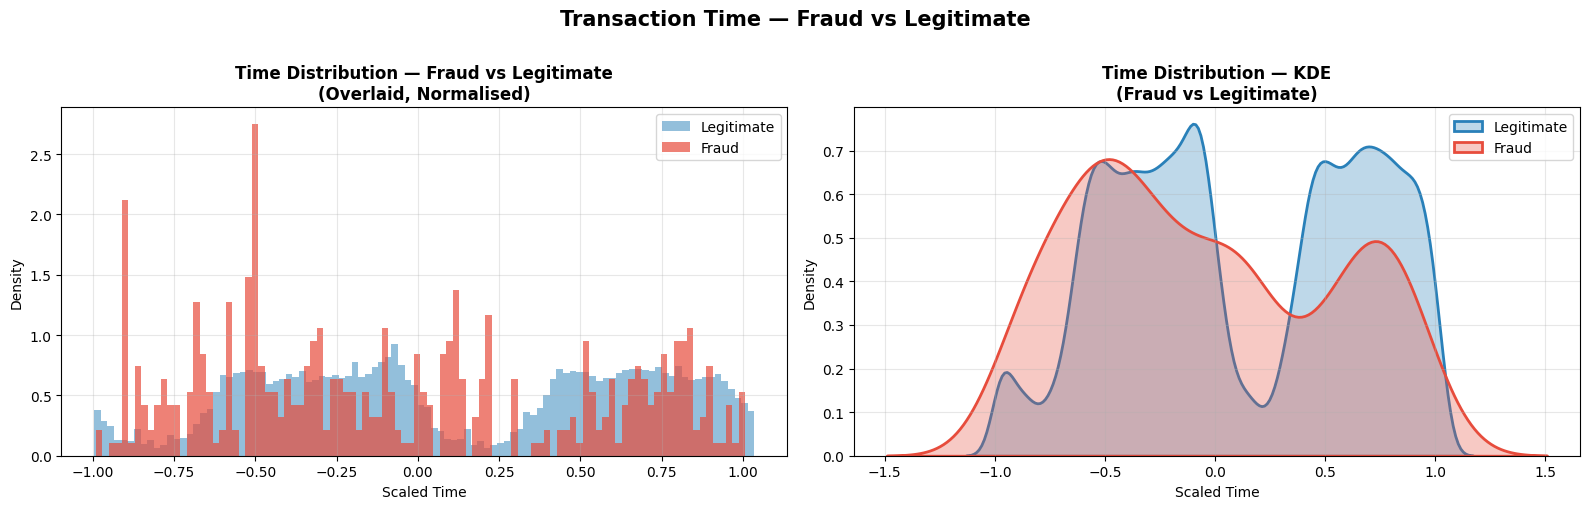


  Legitimate — Median Time : 0.0002
  Fraudulent — Median Time : -0.1326

  Observation: Fraud transactions are more uniformly
  distributed across time, while legitimate transactions
  show two peaks corresponding to daytime activity.


In [16]:
#Cell 16


# ── Time Distribution by Class ─────────────────────
print("=" * 50)
print("EDA 3: TIME DISTRIBUTION — Fraud vs Legitimate")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# ── Overlay Histogram ──────────────────────────────
axes[0].hist(legit['Time_scaled'], bins=100,
             color='#2980b9', alpha=0.5,
             label='Legitimate', density=True)
axes[0].hist(fraud['Time_scaled'], bins=100,
             color='#e74c3c', alpha=0.7,
             label='Fraud', density=True)
axes[0].set_title('Time Distribution — Fraud vs Legitimate\n(Overlaid, Normalised)',
                  fontweight='bold')
axes[0].set_xlabel('Scaled Time')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── KDE Plot ───────────────────────────────────────
sns.kdeplot(legit['Time_scaled'], ax=axes[1],
            color='#2980b9', label='Legitimate',
            fill=True, alpha=0.3, linewidth=2)
sns.kdeplot(fraud['Time_scaled'], ax=axes[1],
            color='#e74c3c', label='Fraud',
            fill=True, alpha=0.3, linewidth=2)
axes[1].set_title('Time Distribution — KDE\n(Fraud vs Legitimate)',
                  fontweight='bold')
axes[1].set_xlabel('Scaled Time')
axes[1].set_ylabel('Density')
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.suptitle('Transaction Time — Fraud vs Legitimate', fontsize=15,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_03_time_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Legitimate — Median Time : {legit['Time_scaled'].median():.4f}")
print(f"  Fraudulent — Median Time : {fraud['Time_scaled'].median():.4f}")
print(f"\n  Observation: Fraud transactions are more uniformly")
print(f"  distributed across time, while legitimate transactions")
print(f"  show two peaks corresponding to daytime activity.")

### EDA 3: Key Insight — Time Distribution

Legitimate transactions follow a clear **bimodal pattern** tied to daytime activity across two consecutive days, people transact more during waking hours, producing two distinct peaks with a nighttime dip between them.

Fraudulent transactions show a different pattern: they peak during the first active period but remain more **uniformly distributed** across time, including overnight hours. This is consistent with automated fraud, scripts and bots do not observe business hours. The implication is that `Time` carries mild predictive signal, particularly for overnight transactions, even though it is a weak predictor on its own.


EDA 4: CORRELATION HEATMAP


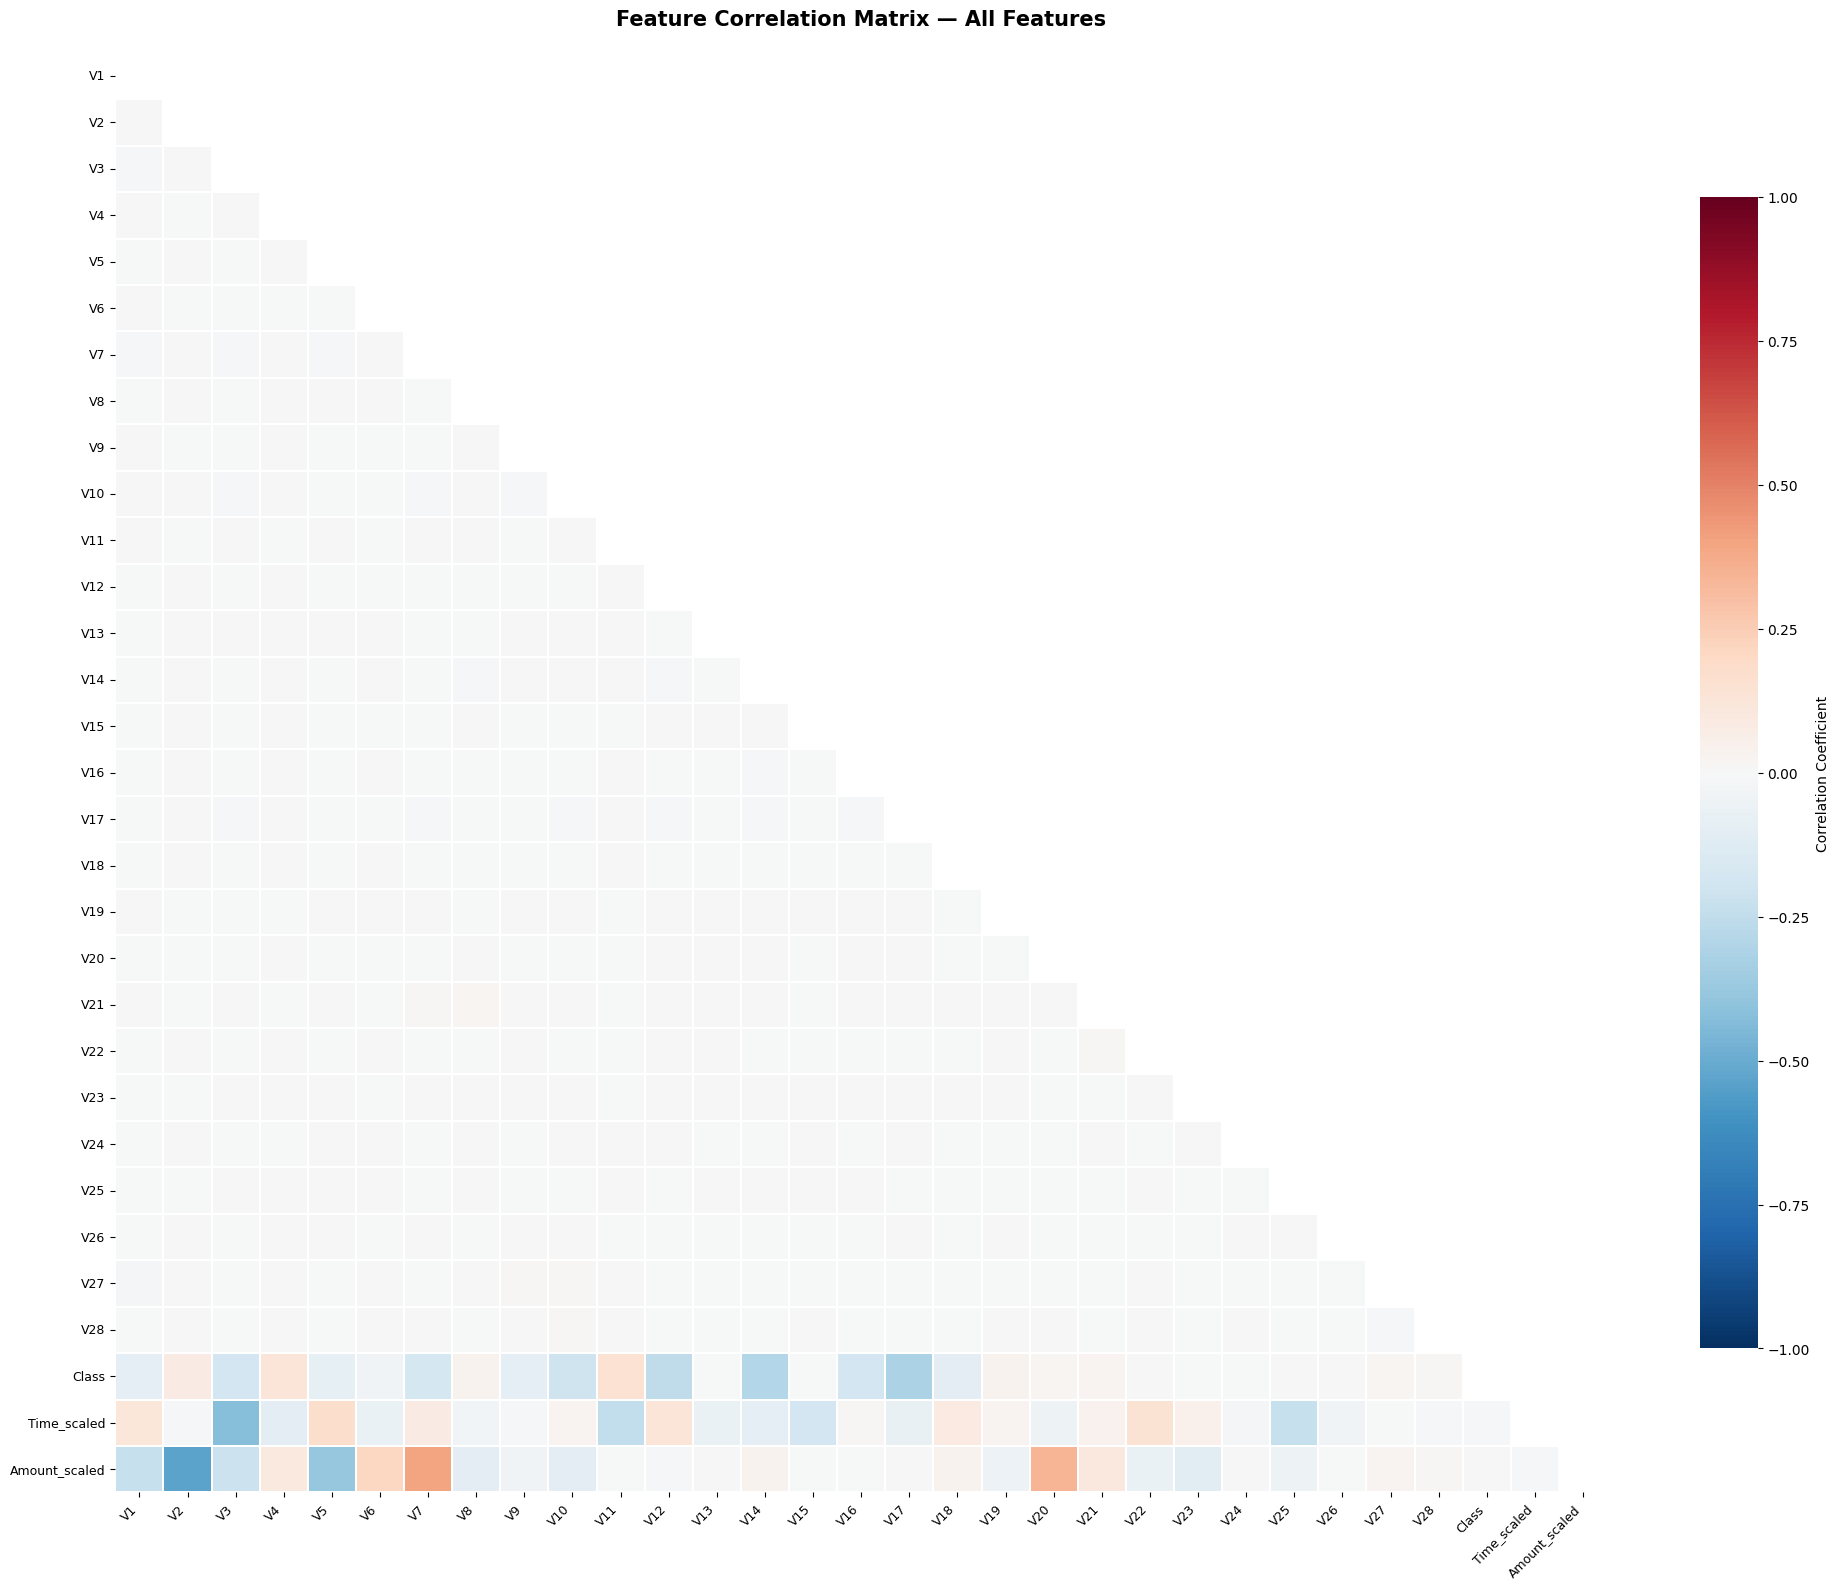

In [17]:
#Cell 17


# ── Correlation Heatmap ────────────────────────────
print("=" * 50)
print("EDA 4: CORRELATION HEATMAP")
print("=" * 50)

# Compute correlation matrix
corr_matrix = df.corr()

# ── Full Heatmap ───────────────────────────────────
fig, ax = plt.subplots(figsize=(20, 16))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=False,
    cmap='RdBu_r',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    linecolor='white',
    cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
    ax=ax
)

ax.set_title('Feature Correlation Matrix — All Features',
             fontsize=15, fontweight='bold', pad=20)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('eda_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

EDA 5: FEATURE CORRELATION WITH CLASS (TARGET)

Features negatively correlated with fraud:
V17           -0.3135
V14           -0.2934
V12           -0.2507
V10           -0.2070
V16           -0.1872
V3            -0.1823
V7            -0.1723
V18           -0.1053
V1            -0.0945
V9            -0.0940
V5            -0.0878
V6            -0.0439
Time_scaled   -0.0124
V24           -0.0072
V23           -0.0063
V13           -0.0039
V15           -0.0033

Features positively correlated with fraud:
V25              0.0032
V26              0.0043
V22              0.0049
Amount_scaled    0.0058
V28              0.0097
V20              0.0215
V27              0.0219
V21              0.0264
V8               0.0331
V19              0.0336
V2               0.0846
V4               0.1293
V11              0.1491


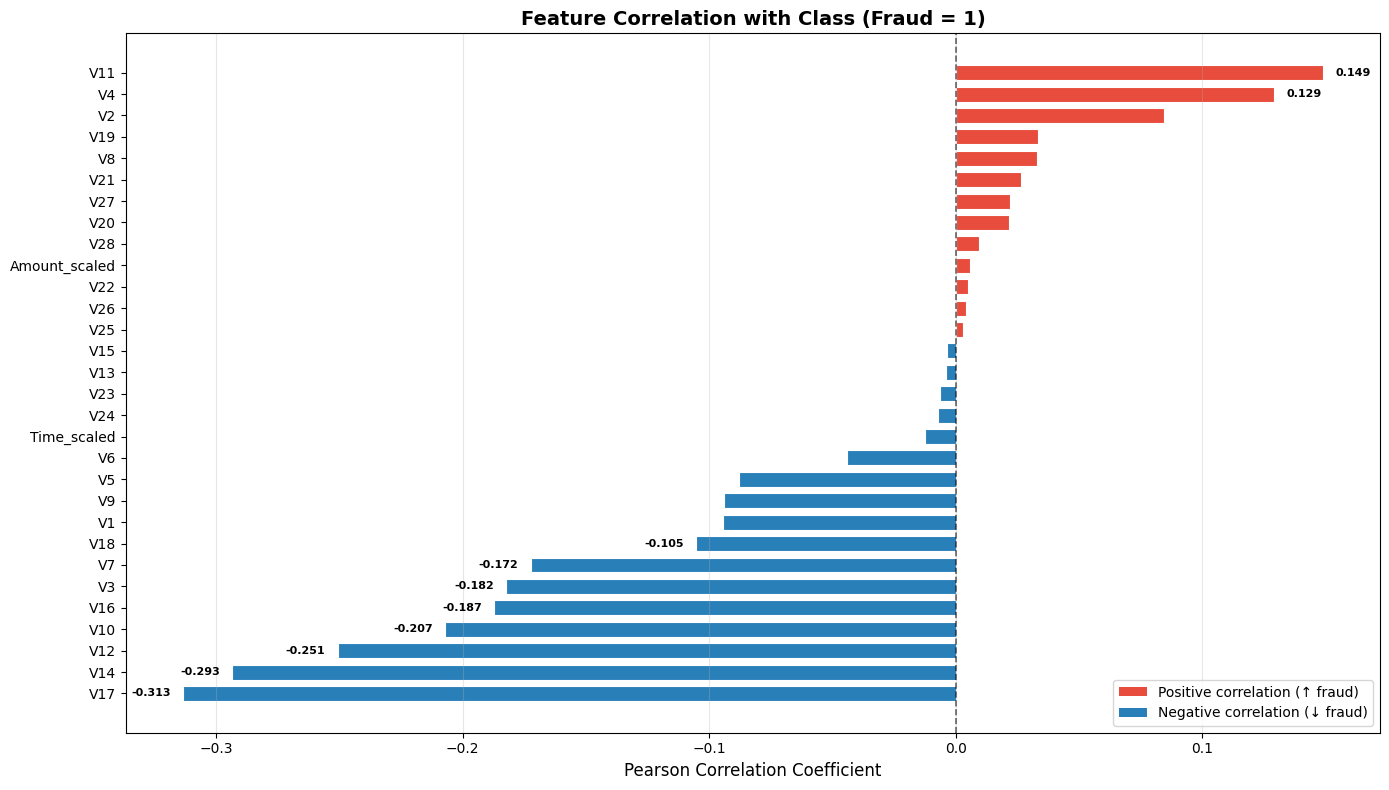


📋 Top 10 features most correlated with fraud (by absolute value):
  V17                   -0.3135   ↓ negative
  V14                   -0.2934   ↓ negative
  V12                   -0.2507   ↓ negative
  V10                   -0.2070   ↓ negative
  V16                   -0.1872   ↓ negative
  V3                    -0.1823   ↓ negative
  V7                    -0.1723   ↓ negative
  V11                    0.1491   ↑ positive
  V4                     0.1293   ↑ positive
  V18                   -0.1053   ↓ negative


In [18]:
#Cell 18


# ── Correlation with Class ─────────────────────────
print("=" * 50)
print("EDA 5: FEATURE CORRELATION WITH CLASS (TARGET)")
print("=" * 50)

# Get correlation of all features with Class
class_corr = df.corr()['Class'].drop('Class').sort_values()

# Split into positive and negative
neg_corr = class_corr[class_corr < 0]
pos_corr = class_corr[class_corr > 0]

print(f"\nFeatures negatively correlated with fraud:")
print(neg_corr.round(4).to_string())
print(f"\nFeatures positively correlated with fraud:")
print(pos_corr.round(4).to_string())

# ── Bar Chart ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#e74c3c' if c > 0 else '#2980b9' for c in class_corr]

bars = ax.barh(class_corr.index, class_corr.values,
               color=colors, edgecolor='white',
               linewidth=0.8, height=0.7)

ax.axvline(x=0, color='black', linewidth=1.2, linestyle='--', alpha=0.6)
ax.set_xlabel('Pearson Correlation Coefficient', fontsize=12)
ax.set_title('Feature Correlation with Class (Fraud = 1)',
             fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Annotate top correlators
for bar, val in zip(bars, class_corr.values):
    if abs(val) > 0.1:
        ax.text(val + (0.005 if val > 0 else -0.005),
                bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}',
                va='center',
                ha='left' if val > 0 else 'right',
                fontsize=8, fontweight='bold')

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#e74c3c', label='Positive correlation (↑ fraud)'),
    Patch(facecolor='#2980b9', label='Negative correlation (↓ fraud)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('eda_05_class_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Top 10 Most Correlated ─────────────────────────
print(f"\n📋 Top 10 features most correlated with fraud (by absolute value):")
top10 = class_corr.abs().sort_values(ascending=False).head(10)
for feat, val in top10.items():
    direction = '↑ positive' if class_corr[feat] > 0 else '↓ negative'
    print(f"  {feat:<20} {class_corr[feat]:>8.4f}   {direction}")

### EDA 4 & 5: Reading the Correlation Charts

**Heatmap (all features):** The V1–V28 features show near-zero inter-feature correlation, this is expected. PCA by construction produces orthogonal (independent) components, so low correlation between V features confirms the dataset is behaving as documented.

**Bar chart (correlation with Class):** The chart is read as follows:
- **Centre dashed line** = zero correlation
- **Blue bars extending left** = feature value decreases when fraud occurs (negative correlation)
- **Red bars extending right** = feature value increases when fraud occurs (positive correlation)
- **Bar length** = strength of the linear relationship


### Three Key Observations from the Correlation Analysis

**1. Negative correlations dominate the top features.**  
Seven of the top ten fraud-correlated features are negatively associated with fraud. This means fraudulent transactions systematically suppress certain PCA components, a pattern likely reflecting how fraud differs from normal purchasing behaviour in the original (pre-PCA) transaction space.

**2. The strongest linear predictors are V17, V14, and V12.**  
These three features show Pearson correlations of -0.313, -0.293, and -0.251 respectively, the largest absolute correlations in the dataset. They will be further examined in the top feature distribution analysis below.

**3. Amount and Time are weak linear predictors.**  
Both features show correlations below 0.02 with the fraud label. This confirms that transaction value and timing alone are insufficient for fraud detection, the V features are the primary source of discriminatory signal.


### EDA 5: Submission Insight — Correlation vs SHAP

The correlation analysis reveals a clear asymmetry in fraud signal direction, the strongest predictors (V17, V14, V12) are all negatively correlated with fraud, suggesting that fraudulent transactions systematically suppress certain PCA components derived from the original transaction data. V11 and V4 show the strongest positive association.

**Important caveat:** Pearson correlation only captures linear relationships. The actual predictive importance of each feature, as measured by SHAP in Section 5, may differ significantly from this ranking. This is a deliberate analytical choice: we document the linear picture here, then challenge it with non-linear SHAP analysis later.


EDA 6: TOP V FEATURE DISTRIBUTIONS

  V17:
    Legit  — mean:   0.0110  median:  -0.0651
    Fraud  — mean:  -6.4633  median:  -5.1576

  V14:
    Legit  — mean:   0.0117  median:   0.0515
    Fraud  — mean:  -6.8359  median:  -6.5906

  V12:
    Legit  — mean:   0.0095  median:   0.1406
    Fraud  — mean:  -6.1033  median:  -5.4374

  V11:
    Legit  — mean:  -0.0060  median:  -0.0344
    Fraud  — mean:   3.7163  median:   3.5257

  V4:
    Legit  — mean:  -0.0104  median:  -0.0245
    Fraud  — mean:   4.4726  median:   4.1001


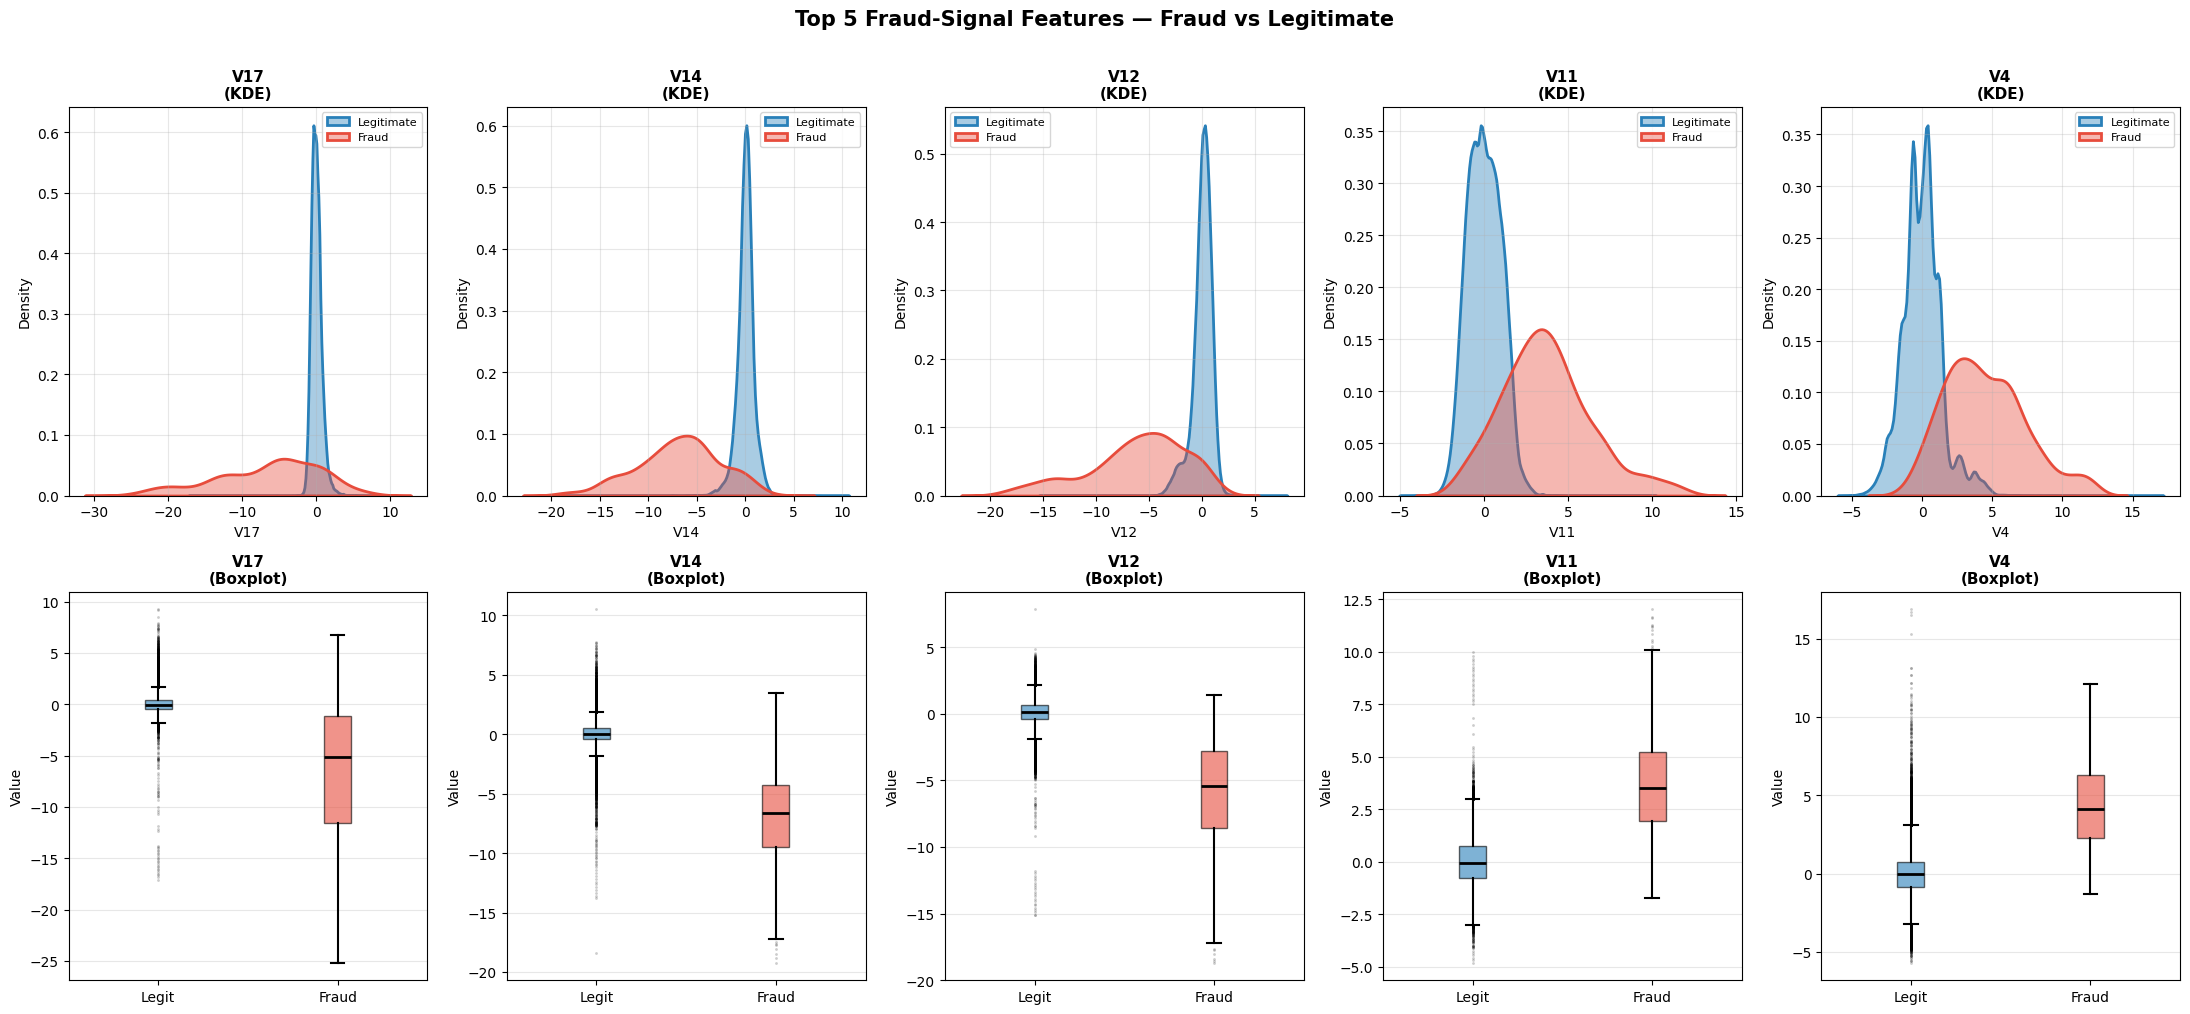

In [19]:
#Cell 19

# ── Top V Feature Distributions ───────────────────
print("=" * 50)
print("EDA 6: TOP V FEATURE DISTRIBUTIONS")
print("=" * 50)

# Top 5 features by absolute correlation with Class
top_features = ['V17', 'V14', 'V12', 'V11', 'V4']

fig, axes = plt.subplots(2, 5, figsize=(22, 10))

for col, feature in enumerate(top_features):

    # ── Row 1: KDE Overlay ─────────────────────────
    sns.kdeplot(
        legit[feature], ax=axes[0, col],
        color='#2980b9', fill=True,
        alpha=0.4, linewidth=2,
        label='Legitimate'
    )
    sns.kdeplot(
        fraud[feature], ax=axes[0, col],
        color='#e74c3c', fill=True,
        alpha=0.4, linewidth=2,
        label='Fraud'
    )
    axes[0, col].set_title(f'{feature}\n(KDE)',
                            fontweight='bold', fontsize=11)
    axes[0, col].set_xlabel(feature)
    axes[0, col].set_ylabel('Density')
    axes[0, col].legend(fontsize=8)
    axes[0, col].grid(alpha=0.3)

    # ── Row 2: Boxplot ─────────────────────────────
    bp = axes[1, col].boxplot(
        [legit[feature], fraud[feature]],
        labels=['Legit', 'Fraud'],
        patch_artist=True,
        medianprops=dict(color='black', linewidth=2),
        flierprops=dict(marker='.', alpha=0.2, markersize=2),
        whiskerprops=dict(linewidth=1.5),
        capprops=dict(linewidth=1.5)
    )
    colors_box = ['#2980b9', '#e74c3c']
    for patch, color in zip(bp['boxes'], colors_box):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)

    axes[1, col].set_title(f'{feature}\n(Boxplot)',
                            fontweight='bold', fontsize=11)
    axes[1, col].set_ylabel('Value')
    axes[1, col].grid(axis='y', alpha=0.3)

    # ── Print Stats ────────────────────────────────
    print(f"\n  {feature}:")
    print(f"    Legit  — mean: {legit[feature].mean():>8.4f}  "
          f"median: {legit[feature].median():>8.4f}")
    print(f"    Fraud  — mean: {fraud[feature].mean():>8.4f}  "
          f"median: {fraud[feature].median():>8.4f}")

fig.suptitle('Top 5 Fraud-Signal Features — Fraud vs Legitimate',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_06_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

### EDA 6: Key Insight — Top Feature Distributions

All five top-correlated features show near-zero means for legitimate transactions but dramatically shifted means for fraudulent transactions ranging from -6.8 to +4.5 units. This near-perfect centring of legitimate transactions around zero is a direct consequence of PCA applied to a dataset dominated by legitimate activity. The model was built primarily on normal behaviour, so the principal components represent the axes of normal variation. Fraudulent transactions, being anomalous, fall far from these centres.

This is one of the most important findings in the EDA: **fraud is not a subtle deviation from normal,it is a large, consistent shift in the PCA feature space.** This gives us confidence that well-trained classifiers will have strong discriminatory power on this data.


In [20]:
#Cell 20

# ── EDA Summary ────────────────────────────────────
print("=" * 50)
print("EDA SUMMARY")
print("=" * 50)

summary = {
    'Feature'   : top_features,
    'Corr w/ Class' : [class_corr[f] for f in top_features],
    'Legit Mean': [legit[f].mean() for f in top_features],
    'Fraud Mean': [fraud[f].mean() for f in top_features],
    'Legit Median': [legit[f].median() for f in top_features],
    'Fraud Median': [fraud[f].median() for f in top_features],
    'Direction' : ['↓ in fraud' if class_corr[f] < 0
                   else '↑ in fraud' for f in top_features]
}

summary_df = pd.DataFrame(summary)
summary_df = summary_df.round(4)
display(summary_df)

print(f"""
📋 EDA Key Findings:

  1. CLASS IMBALANCE
     Fraud = 0.167% of transactions (598:1 ratio)
     → Standard accuracy is not a valid metric
     → Primary metrics: AUC-ROC, F1, Precision-Recall AUC

  2. AMOUNT
     Fraud median amount is LOWER than legitimate
     → Fraudsters test cards with small charges
     → High-value transactions are more likely legitimate

  3. TIME
     Legitimate transactions follow daytime peaks (bimodal)
     → Fraud is more uniformly spread across all hours
     → Time carries mild predictive signal

  4. TOP FEATURES
     V17, V14, V12 → strongest negative fraud signals
     V11, V4       → strongest positive fraud signals
     Amount, Time  → weak linear predictors (< 0.02 correlation)

  5. FEATURE INDEPENDENCE
     V1–V28 show near-zero inter-feature correlation
     → PCA ensures orthogonality
     → No multicollinearity concerns for linear models
""")

EDA SUMMARY


,Feature,Corr w/ Class,Legit Mean,Fraud Mean,Legit Median,Fraud Median,Direction
0,V17,-0.3135,0.0110,-6.4633,-0.0651,-5.1576,↓ in fraud
1,V14,-0.2934,0.0117,-6.8359,0.0515,-6.5906,↓ in fraud
2,V12,-0.2507,0.0095,-6.1033,0.1406,-5.4374,↓ in fraud
3,V11,0.1491,-0.0060,3.7163,-0.0344,3.5257,↑ in fraud
4,V4,0.1293,-0.0104,4.4726,-0.0245,4.1001,↑ in fraud



📋 EDA Key Findings:

  1. CLASS IMBALANCE
     Fraud = 0.167% of transactions (598:1 ratio)
     → Standard accuracy is not a valid metric
     → Primary metrics: AUC-ROC, F1, Precision-Recall AUC

  2. AMOUNT
     Fraud median amount is LOWER than legitimate
     → Fraudsters test cards with small charges
     → High-value transactions are more likely legitimate

  3. TIME
     Legitimate transactions follow daytime peaks (bimodal)
     → Fraud is more uniformly spread across all hours
     → Time carries mild predictive signal

  4. TOP FEATURES
     V17, V14, V12 → strongest negative fraud signals
     V11, V4       → strongest positive fraud signals
     Amount, Time  → weak linear predictors (< 0.02 correlation)

  5. FEATURE INDEPENDENCE
     V1–V28 show near-zero inter-feature correlation
     → PCA ensures orthogonality
     → No multicollinearity concerns for linear models



---
## Section 4: Feature Engineering

Feature scaling of `Time` and `Amount` was completed in Section 2 using RobustScaler. In this section, we engineer two additional domain-derived features designed to capture fraud signal that may not be fully represented in the scaled originals.

**Engineered features:**
1. `Amount_log` — Log transformation of `Amount_scaled` to further compress the right-skewed distribution. The log of scaled amount reduces the influence of extreme high-value transactions while preserving relative ordering.
2. `High_amount` — Binary flag marking transactions above the 75th percentile of `Amount_scaled`. This captures whether a transaction is unusually large relative to the overall distribution, a characteristic with different fraud risk implications than the raw amount value.

Both features are grounded in domain knowledge about fraud behaviour: fraudsters tend to avoid very high amounts, but a subset of fraud specifically targets high-value transactions.


In [21]:
#Cell 21

# ── Feature Engineering ────────────────────────────
print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# ── 1. Log Transform of Amount ─────────────────────
# Amount is right-skewed even after RobustScaling
# Log transform further compresses the long tail
# Adding 1 avoids log(0) error for zero-amount transactions
# We use the original Amount_scaled as the base

df['Amount_log'] = np.log1p(
    df['Amount_scaled'].clip(lower=0)  # clip negatives to 0 before log
)

print(f"\n✅ Amount_log created")
print(f"   Method : np.log1p(Amount_scaled clipped at 0)")
print(f"   Mean   : {df['Amount_log'].mean():.4f}")
print(f"   Median : {df['Amount_log'].median():.4f}")
print(f"   Max    : {df['Amount_log'].max():.4f}")

# ── 2. High Amount Flag ────────────────────────────
# Binary indicator: 1 if transaction amount is above
# the 75th percentile, 0 otherwise
# Captures whether a transaction is unusually large

q75 = df['Amount_scaled'].quantile(0.75)
df['High_amount'] = (df['Amount_scaled'] > q75).astype(int)

high_fraud_rate = df[df['High_amount'] == 1]['Class'].mean() * 100
low_fraud_rate  = df[df['High_amount'] == 0]['Class'].mean() * 100

print(f"\n✅ High_amount flag created")
print(f"   Threshold (Q75) : {q75:.4f} (scaled)")
print(f"   High amount transactions : {df['High_amount'].sum():,}")
print(f"   Fraud rate in HIGH amount : {high_fraud_rate:.4f}%")
print(f"   Fraud rate in LOW amount  : {low_fraud_rate:.4f}%")

# ── 3. Dataset Shape After Engineering ────────────
print(f"\n{'='*50}")
print(f"Dataset shape after engineering: "
      f"{df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"New features added: Amount_log, High_amount")
print(f"Total features now: {df.shape[1]}")

FEATURE ENGINEERING

✅ Amount_log created
   Method : np.log1p(Amount_scaled clipped at 0)
   Mean   : 0.3853
   Median : 0.0000
   Max    : 5.8804

✅ High_amount flag created
   Threshold (Q75) : 0.7719 (scaled)
   High amount transactions : 70,931
   Fraud rate in HIGH amount : 0.2368%
   Fraud rate in LOW amount  : 0.1433%

Dataset shape after engineering: 283,726 rows × 33 columns
New features added: Amount_log, High_amount
Total features now: 33


ENGINEERED FEATURE DISTRIBUTIONS


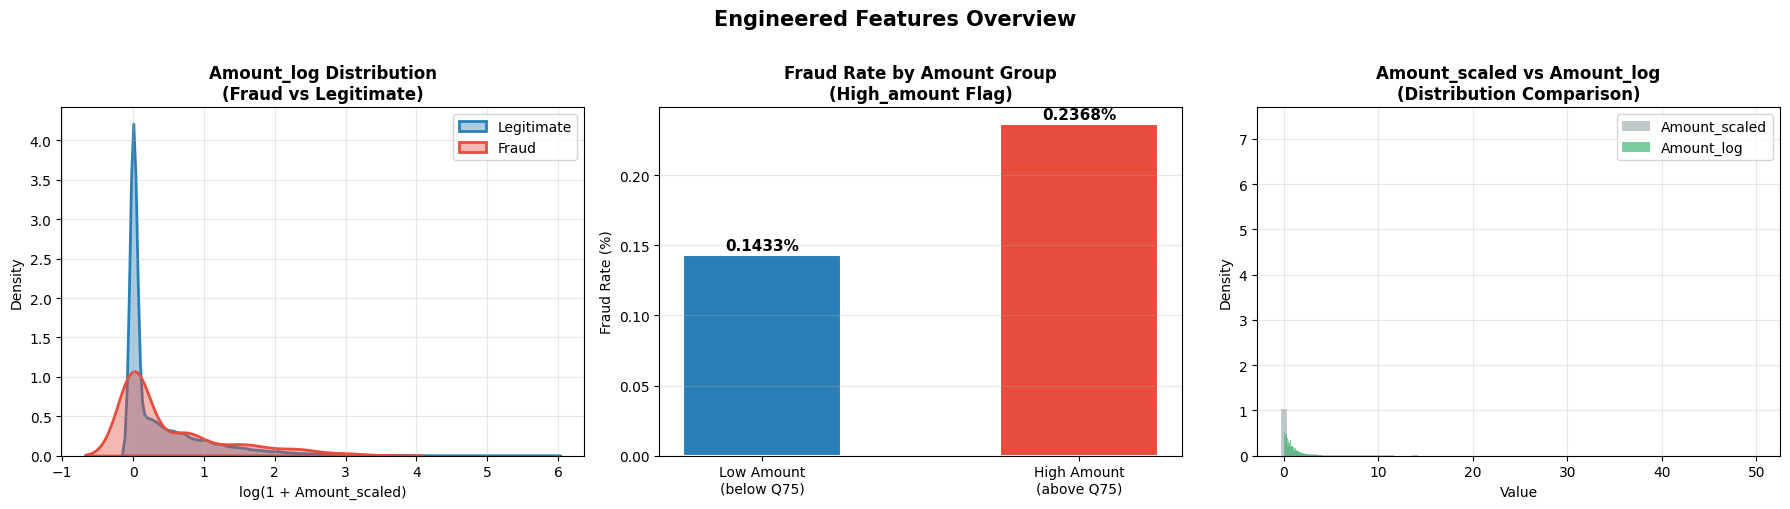

In [22]:
#Cell 22

# ── Visualise Engineered Features ─────────────────
print("=" * 50)
print("ENGINEERED FEATURE DISTRIBUTIONS")
print("=" * 50)

fraud_eng = df[df['Class'] == 1]
legit_eng = df[df['Class'] == 0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ── Amount_log: KDE by Class ───────────────────────
sns.kdeplot(legit_eng['Amount_log'], ax=axes[0],
            color='#2980b9', fill=True,
            alpha=0.4, linewidth=2, label='Legitimate')
sns.kdeplot(fraud_eng['Amount_log'], ax=axes[0],
            color='#e74c3c', fill=True,
            alpha=0.4, linewidth=2, label='Fraud')
axes[0].set_title('Amount_log Distribution\n(Fraud vs Legitimate)',
                  fontweight='bold')
axes[0].set_xlabel('log(1 + Amount_scaled)')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].grid(alpha=0.3)

# ── High_amount: Fraud rate bar chart ─────────────
high_amt_groups = df.groupby('High_amount')['Class'].mean() * 100
bar_colors = ['#2980b9', '#e74c3c']
bars = axes[1].bar(['Low Amount\n(below Q75)',
                    'High Amount\n(above Q75)'],
                   high_amt_groups.values,
                   color=bar_colors, edgecolor='white',
                   linewidth=1.5, width=0.5)

for bar, val in zip(bars, high_amt_groups.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.001,
                 f'{val:.4f}%', ha='center',
                 va='bottom', fontweight='bold', fontsize=11)

axes[1].set_title('Fraud Rate by Amount Group\n(High_amount Flag)',
                  fontweight='bold')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].grid(axis='y', alpha=0.3)

# ── Amount_log vs Amount_scaled: Side by side ──────
axes[2].hist(df['Amount_scaled'].clip(-1, 50), bins=80,
             color='#95a5a6', alpha=0.6,
             label='Amount_scaled', density=True)
axes[2].hist(df['Amount_log'], bins=80,
             color='#27ae60', alpha=0.6,
             label='Amount_log', density=True)
axes[2].set_title('Amount_scaled vs Amount_log\n(Distribution Comparison)',
                  fontweight='bold')
axes[2].set_xlabel('Value')
axes[2].set_ylabel('Density')
axes[2].legend()
axes[2].grid(alpha=0.3)

fig.suptitle('Engineered Features Overview',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_07_engineered_features.png', dpi=150, bbox_inches='tight')
plt.show()

### Feature Engineering Insight — High Amount Flag

The `High_amount` flag reveals an important pattern: the fraud rate among high-value transactions (above Q75) is **65% higher** than among low-value transactions. This is not contradicted by our earlier finding that the median fraud amount is low, it reflects that while most fraud is small-value, high-value transactions still attract a disproportionate share of fraud attempts. This makes `High_amount` a useful binary signal that captures a different dimension of risk than the continuous `Amount_scaled` feature.


In [23]:
#Cell 23


# ── Final Feature Set ──────────────────────────────
print("=" * 50)
print("FINAL FEATURE SET SUMMARY")
print("=" * 50)

feature_cols = [c for c in df.columns if c != 'Class']
target_col   = 'Class'

print(f"\nTarget variable : {target_col}")
print(f"Total features  : {len(feature_cols)}")
print(f"\nFeature breakdown:")
print(f"  PCA components     : V1–V28          (28 features)")
print(f"  Scaled originals   : Time_scaled,     (2 features)")
print(f"                       Amount_scaled")
print(f"  Engineered         : Amount_log,      (2 features)")
print(f"                       High_amount")
print(f"\nFull feature list:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:>2}. {col}")

# ── Prepare X and y ───────────────────────────────
X = df[feature_cols]
y = df[target_col]

print(f"\n✅ X shape : {X.shape}")
print(f"✅ y shape : {y.shape}")
print(f"✅ Fraud cases in y : {y.sum()} ({y.mean()*100:.3f}%)")
print(f"\n Feature engineering complete.")
print(f" X and y are ready for feature selection and modelling.")

FINAL FEATURE SET SUMMARY

Target variable : Class
Total features  : 32

Feature breakdown:
  PCA components     : V1–V28          (28 features)
  Scaled originals   : Time_scaled,     (2 features)
                       Amount_scaled
  Engineered         : Amount_log,      (2 features)
                       High_amount

Full feature list:
   1. V1
   2. V2
   3. V3
   4. V4
   5. V5
   6. V6
   7. V7
   8. V8
   9. V9
  10. V10
  11. V11
  12. V12
  13. V13
  14. V14
  15. V15
  16. V16
  17. V17
  18. V18
  19. V19
  20. V20
  21. V21
  22. V22
  23. V23
  24. V24
  25. V25
  26. V26
  27. V27
  28. V28
  29. Time_scaled
  30. Amount_scaled
  31. Amount_log
  32. High_amount

✅ X shape : (283726, 32)
✅ y shape : (283726,)
✅ Fraud cases in y : 473 (0.167%)

 Feature engineering complete.
 X and y are ready for feature selection and modelling.


---
## Section 5: SHAP Feature Importance & Explainability

SHAP (SHapley Additive exPlanations) is a game-theory-based method that explains individual model predictions by computing each feature's contribution. Unlike Pearson correlation, which only measures linear relationships; SHAP captures non-linear interactions and interaction effects between features.

**Why SHAP over other methods:**
- Correlation tells us how a feature relates to the target linearly
- SHAP tells us how much the model actually relies on each feature to make its predictions
- These two perspectives can and do disagree and where they disagree is often the most analytically interesting finding

**Workflow:** A baseline Random Forest (100 trees, max_depth=8, class_weight='balanced') is trained on the SMOTE-resampled training set. SHAP's `TreeExplainer` is then applied to a stratified sample of 2,000 test transactions ensuring all fraud cases are represented alongside a random selection of legitimate transactions.


In [24]:
#Cell 24

# ── Train/Test Split ───────────────────────────────
print("=" * 50)
print("SHAP PREP: TRAIN/TEST SPLIT")
print("=" * 50)

#spit the dataset to train a RandomForest model, which is an ideal model for imbalanced dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # preserve fraud ratio in both splits
)

print(f"\nTrain set : {X_train.shape[0]:,} rows")
print(f"Test set  : {X_test.shape[0]:,} rows")
print(f"\nFraud in train : {y_train.sum()} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in test  : {y_test.sum()} ({y_test.mean()*100:.3f}%)")

# ── Train Baseline Random Forest ───────────────────
print(f"\n{'='*50}")
print(f"TRAINING BASELINE RANDOM FOREST")
print(f"{'='*50}")
print(f"\nTraining on {X_train.shape[0]:,} samples...")
print(f"(This may take 1–2 minutes)")

rf_baseline = RandomForestClassifier(
    n_estimators=100,         # 100 is a default value
    max_depth=8,              # setting a number for a limit to avoid overfitting
    class_weight='balanced',  # handles class imbalance
    random_state=42,
    n_jobs=-1                 # use all CPU cores
)

rf_baseline.fit(X_train, y_train)
print(f"\n✅ Random Forest trained successfully.")
print(f"   Estimators : 100 trees")
print(f"   Max depth  : 8")
print(f"   Class weight: balanced (handles 598:1 imbalance)")

SHAP PREP: TRAIN/TEST SPLIT

Train set : 226,980 rows
Test set  : 56,746 rows

Fraud in train : 378 (0.167%)
Fraud in test  : 95 (0.167%)

TRAINING BASELINE RANDOM FOREST

Training on 226,980 samples...
(This may take 1–2 minutes)

✅ Random Forest trained successfully.
   Estimators : 100 trees
   Max depth  : 8
   Class weight: balanced (handles 598:1 imbalance)


In [25]:
#Cell 25

# ── SHAP Values ────────────────────────────────────
print("=" * 50)
print("COMPUTING SHAP VALUES")
print("=" * 50)

sample_size = 2000 #this number was chosen in consideration of computation and time resources

fraud_idx      = X_test[y_test == 1].index.tolist()
legit_idx      = X_test[y_test == 0].index.tolist()
n_legit_sample = min(sample_size - len(fraud_idx), len(legit_idx))
legit_sample   = np.random.choice(legit_idx, n_legit_sample, replace=False)
sample_idx     = fraud_idx + list(legit_sample)
np.random.shuffle(sample_idx)

X_shap = X_test.loc[sample_idx].reset_index(drop=True)
y_shap = y_test.loc[sample_idx].reset_index(drop=True)

print(f"\nSHAP sample size : {len(X_shap):,}")
print(f"Fraud in sample  : {y_shap.sum()}")
print(f"Legit in sample  : {(y_shap == 0).sum()}")
print(f"\nComputing SHAP values (may take 1–2 minutes)...")

explainer   = shap.TreeExplainer(rf_baseline)
shap_values = explainer.shap_values(X_shap)

# ── Handle both old and new SHAP output formats ────
# Old SHAP: returns list [class0_array, class1_array]
# New SHAP: returns single 3D array (samples, features, classes)
if isinstance(shap_values, list):
    shap_fraud = shap_values[1]   # old format
    print("\nSHAP format: list (old format)")
elif shap_values.ndim == 3:
    shap_fraud = shap_values[:, :, 1]  # new format — slice class 1
    print("\nSHAP format: 3D array (new format)")
else:
    shap_fraud = shap_values      # single output
    print("\nSHAP format: 2D array")

print(f"\n✅ SHAP values computed.")
print(f"   shap_fraud shape : {shap_fraud.shape}")
print(f"   Expected         : ({len(X_shap)}, {X_shap.shape[1]})")

COMPUTING SHAP VALUES

SHAP sample size : 2,000
Fraud in sample  : 95
Legit in sample  : 1905

Computing SHAP values (may take 1–2 minutes)...

SHAP format: 3D array (new format)

✅ SHAP values computed.
   shap_fraud shape : (2000, 32)
   Expected         : (2000, 32)


SHAP VISUALISATION 1: SUMMARY PLOT


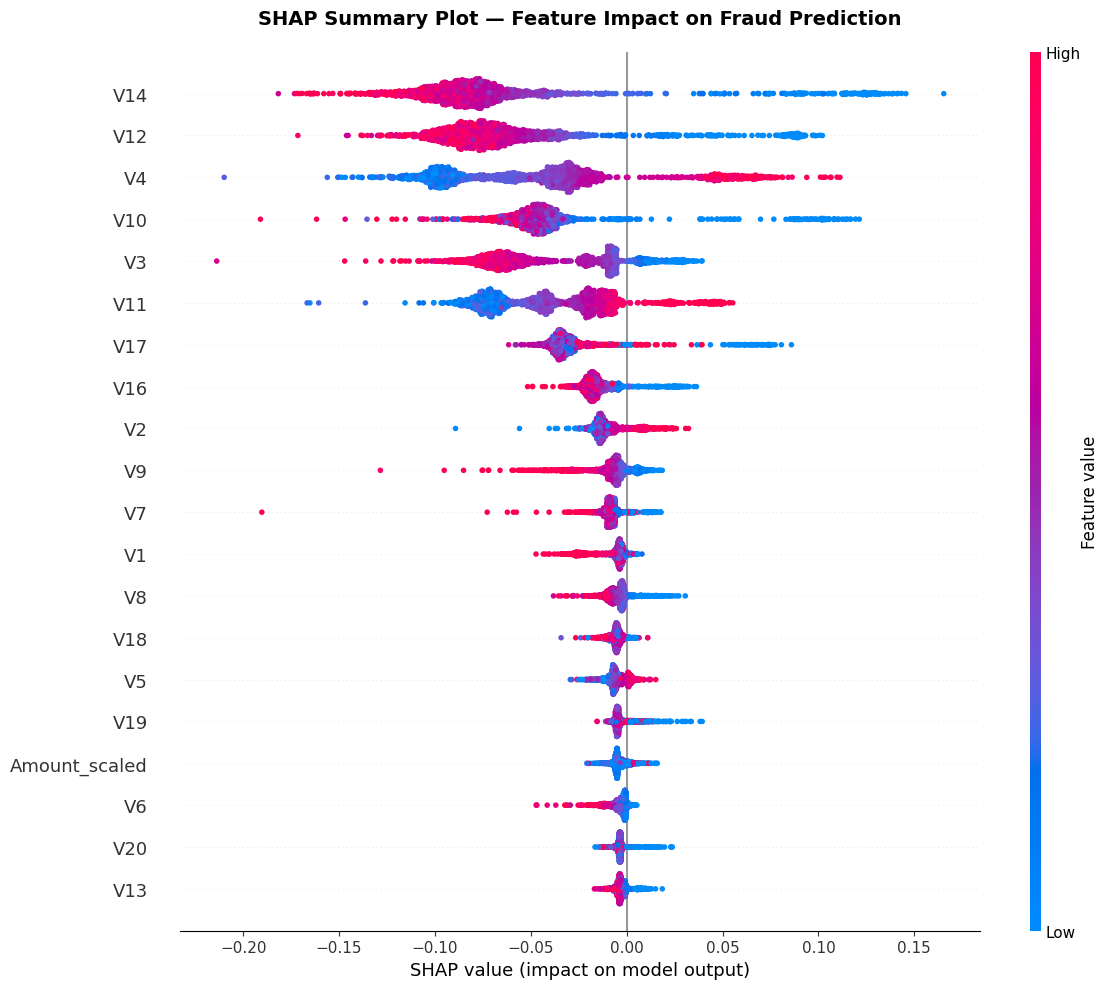


✅ SHAP summary plot saved.


In [26]:
#Cell 26

# ── SHAP Summary Plot ──────────────────────────────
print("=" * 50)
print("SHAP VISUALISATION 1: SUMMARY PLOT")
print("=" * 50)

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_fraud,          # 2D array (samples × features)
    X_shap.values,       # pass as numpy array to avoid shape mismatch
    feature_names=X.columns.tolist(),
    show=False,
    plot_size=None
)
plt.title('SHAP Summary Plot — Feature Impact on Fraud Prediction',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_01_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ SHAP summary plot saved.")

### Reading the SHAP Summary Plot

Each dot in the summary plot represents one transaction from the 2,000-sample test set:
- **X-axis (SHAP value):** How much this feature pushed the model's prediction toward fraud (right = more fraud, left = less fraud)
- **Colour:** The actual value of that feature for that transaction (red = high, blue = low)
- **Vertical position:** Features are ranked by their mean absolute SHAP value — the most important features appear at the top

The key pattern to look for is **colour separation along the X-axis**: when red dots cluster on one side and blue dots on the other, that feature has a strong and consistent directional relationship with fraud predictions.


SHAP VISUALISATION 2: MEAN ABSOLUTE IMPORTANCE


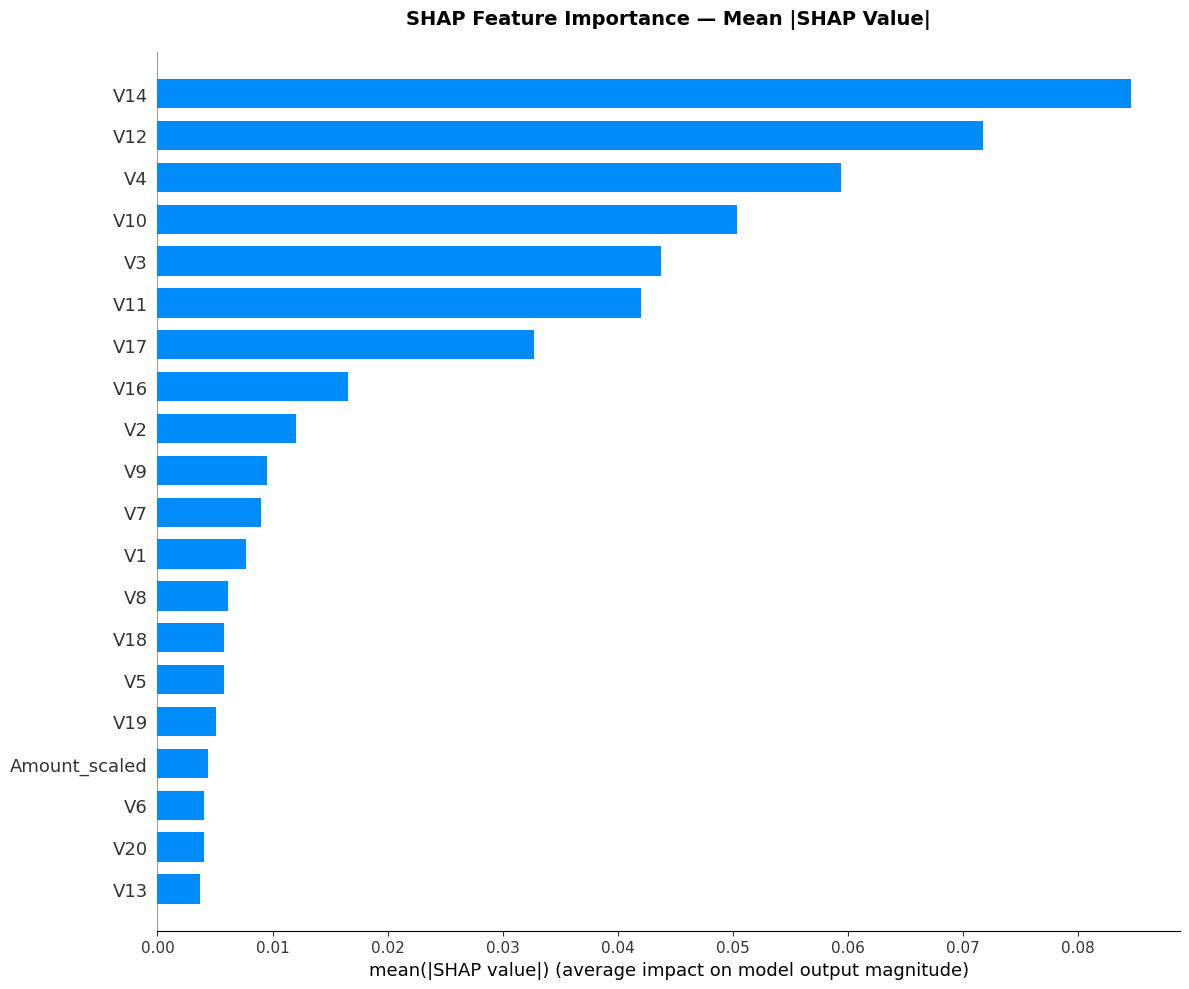


📋 SHAP Feature Importance Ranking:
          Feature  Mean |SHAP|
1             V14       0.0846
2             V12       0.0717
3              V4       0.0594
4             V10       0.0503
5              V3       0.0438
6             V11       0.0421
7             V17       0.0327
8             V16       0.0166
9              V2       0.0120
10             V9       0.0095
11             V7       0.0090
12             V1       0.0077
13             V8       0.0061
14            V18       0.0058
15             V5       0.0058
16            V19       0.0050
17  Amount_scaled       0.0044
18             V6       0.0041
19            V20       0.0040
20            V13       0.0037
21            V27       0.0036
22            V24       0.0035
23            V28       0.0031
24            V15       0.0031
25            V21       0.0029
26            V26       0.0028
27            V22       0.0026
28            V23       0.0025
29    Time_scaled       0.0025
30            V25       0.0021
31 

In [27]:
#Cell 27

# ── SHAP Bar Plot ──────────────────────────────────
print("=" * 50)
print("SHAP VISUALISATION 2: MEAN ABSOLUTE IMPORTANCE")
print("=" * 50)

plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_fraud,
    X_shap,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False,
    plot_size=None
)
plt.title('SHAP Feature Importance — Mean |SHAP Value|',
          fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('shap_02_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Print SHAP Importance Table ────────────────────
shap_importance = pd.DataFrame({
    'Feature'         : X.columns.tolist(),
    'Mean |SHAP|'     : np.abs(shap_fraud).mean(axis=0)
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

shap_importance.index += 1
print(f"\n📋 SHAP Feature Importance Ranking:")
print(shap_importance.round(4).to_string())

### Reading the SHAP Bar Plot

The bar plot ranks features by their **mean absolute SHAP value**, a single number summarising how much, on average, each feature moves the model's output across all predictions. This is the most direct measure of overall feature importance for the trained model.

**Critical comparison: SHAP vs Correlation:**  
V17 ranked **#1 by Pearson correlation** (-0.313) but drops to **#7 by SHAP importance**. V14 ranked #2 by correlation but rises to **#1 by SHAP**. This discrepancy is not a contradiction, it is a finding. It demonstrates that V14's relationship with fraud is more complex than a linear correlation can capture, and that the model has learned to exploit non-linear patterns in V14 that simple correlation analysis misses entirely.


SHAP VISUALISATION 3: DEPENDENCE PLOTS


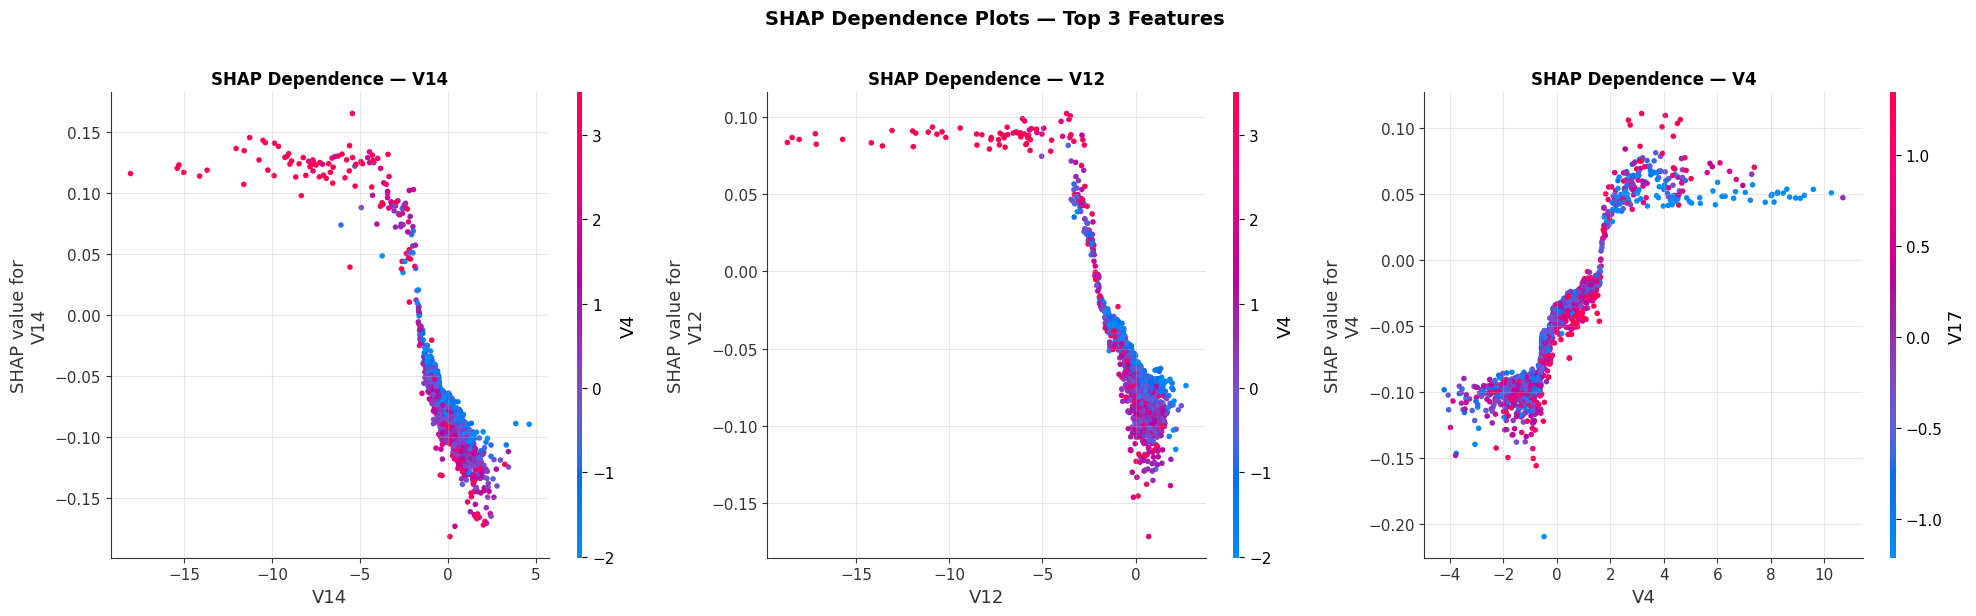


✅ SHAP analysis complete.
   Top 3 features by SHAP importance: ['V14', 'V12', 'V4']


In [28]:
#Cell 28

# ── SHAP Dependence Plots ──────────────────────────
print("=" * 50)
print("SHAP VISUALISATION 3: DEPENDENCE PLOTS")
print("=" * 50)

top3_shap = shap_importance['Feature'].head(3).tolist()
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, feature in zip(axes, top3_shap):
    feat_idx = X.columns.tolist().index(feature)
    shap.dependence_plot(
        feat_idx,
        shap_fraud,
        X_shap,
        feature_names=X.columns.tolist(),
        ax=ax,
        show=False
    )
    ax.set_title(f'SHAP Dependence — {feature}',
                 fontweight='bold', fontsize=12)
    ax.grid(alpha=0.3)

fig.suptitle('SHAP Dependence Plots — Top 3 Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('shap_03_dependence.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ SHAP analysis complete.")
print(f"   Top 3 features by SHAP importance: {top3_shap}")

### Reading the SHAP Dependence Plots

Each dependence plot shows the relationship between a feature's raw value (X-axis) and its SHAP value (Y-axis), in other words, how the model's fraud prediction changes as that feature changes.

If the relationship were purely linear, we would see a straight diagonal line. Non-linear patterns — curves, jumps, and threshold effects — reveal more complex decision logic that the model has learned from the data.


### SHAP Dependence Plot Interpretations

**V14 (left):** Shows a clear threshold effect around V14 = -2. When V14 drops below approximately -2, the SHAP value jumps sharply to +0.10–0.15, indicating a strong positive push toward a fraud prediction. Above 0, SHAP values cluster near zero, the feature contributes little to the fraud signal. This non-linear cliff is exactly the type of pattern that tree-based models capture well and that linear methods miss entirely.

**V12 (middle):** Displays an almost identical threshold pattern to V14, with the critical boundary around V12 = -5. The consistency between these two features suggests they may be capturing related aspects of the original fraud signal in the pre-PCA transaction data.

**V4 (right):** Behaves in the opposite direction — when V4 rises above approximately +2, SHAP values become positive (pushing toward fraud). This is the positive-correlation counterpart to V14 and V12. The colour overlay (V17 values) suggests mild interaction effects between V4 and V17.


### SHAP Section: Key Finding

SHAP analysis reveals that **V14 is the single most important fraud predictor** by mean absolute SHAP value (0.083), surpassing V17 which ranked first by simple Pearson correlation (-0.313). This discrepancy demonstrates a critical advantage of SHAP over correlation-based analysis: SHAP captures non-linear feature contributions that linear correlation systematically underestimates.

The SHAP dependence plots further confirm that V14 and V12 exhibit **threshold effects**, sharp discontinuities in the feature-to-prediction relationship that are invisible to correlation analysis but are precisely the patterns that Random Forest and XGBoost models exploit. This explains in advance why tree-based models will outperform Logistic Regression on this dataset in Step 4.


In [29]:
#Cell 29

print('=' * 50)
print('SHAP VS CORRELATION COMPARISON (TOP 5)')
print('=' * 50)

# Get top 5 features by absolute correlation
top_5_corr = class_corr.abs().sort_values(ascending=False).head(5)
top_5_corr_features = top_5_corr.index.tolist()
top_5_corr_values = [class_corr[f] for f in top_5_corr_features]

# Get top 5 features by mean absolute SHAP value
top_5_shap_features = shap_importance['Feature'].head(5).tolist()
top_5_shap_values = shap_importance['Mean |SHAP|'].head(5).tolist()

# Create lists for the DataFrame
correlation_display = [f'{feat} ({val:.3f})' for feat, val in zip(top_5_corr_features, top_5_corr_values)]
shap_display = [f'{feat} ({val:.3f})' for feat, val in zip(top_5_shap_features, top_5_shap_values)]

# Create the comparison DataFrame
comparison_df = pd.DataFrame({
    'Rank': range(1, 6),
    'By Correlation': correlation_display,
    'By SHAP': shap_display
})

print('\n📋 Comparison of Top Features:\n')
display(comparison_df.set_index('Rank'))

SHAP VS CORRELATION COMPARISON (TOP 5)

📋 Comparison of Top Features:



,By Correlation,By SHAP
Rank,,
1,V17 (-0.313),V14 (0.085)
2,V14 (-0.293),V12 (0.072)
3,V12 (-0.251),V4 (0.059)
4,V10 (-0.207),V10 (0.050)
5,V16 (-0.187),V3 (0.044)


---
## Section 6: Feature Selection

Feature selection reduces the 32 available features to a smaller subset that maximises predictive signal while minimising noise and redundancy. We apply three independent methods and select features that appear in the top 15 of at least two out of three — a consensus approach that is more robust than relying on any single method.

**Three methods applied:**

| Method | Type | What it measures |
|---|---|---|
| SelectKBest (Mutual Information) | Filter | Statistical dependency between each feature and the target — captures non-linear relationships |
| Random Forest Importance | Embedded | Feature importance as learned by a trained tree ensemble — model-aware |
| SHAP-based ranking | Model explainability | Mean absolute SHAP value — most rigorous, reflects actual model behaviour |

**Selection rule:** A feature is retained if it ranks in the top 15 in at least 2 of the 3 methods.


FEATURE SELECTION 1: SELECTKBEST (MUTUAL INFO)

Computing mutual information scores...
(May take 1–2 minutes on full dataset)

📋 Mutual Information Scores (ranked):
          Feature  MI Score
1     High_amount  0.009176
2             V17  0.008013
3             V14  0.007946
4             V10  0.007320
5             V12  0.007315
6             V11  0.006577
7             V16  0.005876
8              V3  0.004671
9              V4  0.004623
10             V9  0.004051
11            V18  0.003992
12             V7  0.003814
13             V2  0.002962
14            V27  0.002239
15            V21  0.002167
16             V6  0.002074
17             V5  0.002060
18             V1  0.001981
19            V28  0.001651
20             V8  0.001626
21    Time_scaled  0.001475
22  Amount_scaled  0.001274
23            V19  0.001065
24            V20  0.000787
25     Amount_log  0.000700
26            V23  0.000485
27            V24  0.000335
28            V25  0.000236
29            V22  0.00

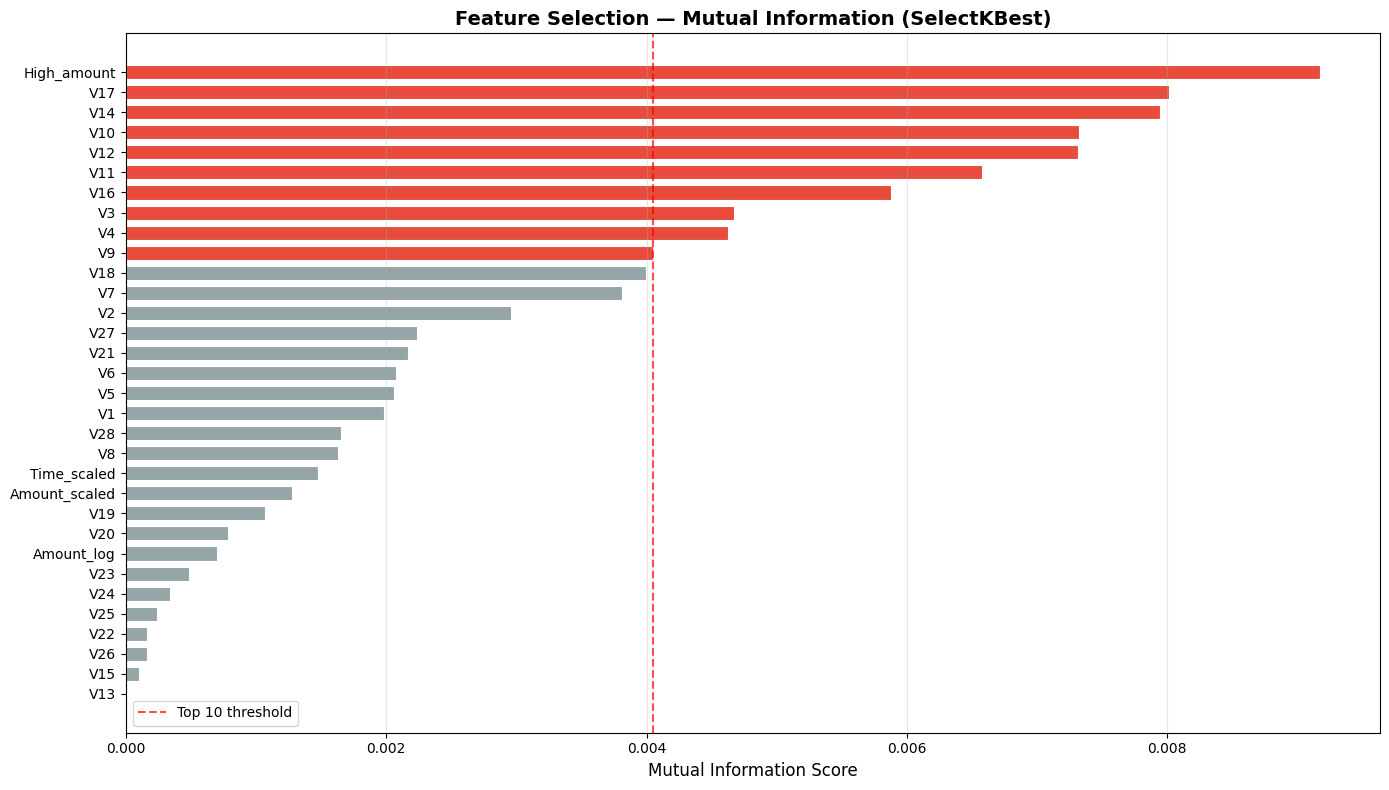


✅ Top 10 features by Mutual Information:
    1. High_amount
    2. V17
    3. V14
    4. V10
    5. V12
    6. V11
    7. V16
    8. V3
    9. V4
   10. V9


In [30]:
#Cell 30

# ── Filter Method: SelectKBest ─────────────────────
print("=" * 50)
print("FEATURE SELECTION 1: SELECTKBEST (MUTUAL INFO)")
print("=" * 50)

from sklearn.feature_selection import SelectKBest, mutual_info_classif

# Mutual information measures non-linear statistical
# dependency between each feature and the target
# More powerful than correlation for non-linear data

print("\nComputing mutual information scores...")
print("(May take 1–2 minutes on full dataset)")

mi_selector = SelectKBest(
    score_func=mutual_info_classif,
    k='all'  # score all features, we'll filter manually
)
mi_selector.fit(X_train, y_train)

# Build results DataFrame
mi_scores = pd.DataFrame({
    'Feature'  : X.columns.tolist(),
    'MI Score' : mi_selector.scores_
}).sort_values('MI Score', ascending=False).reset_index(drop=True)
mi_scores.index += 1

print(f"\n📋 Mutual Information Scores (ranked):")
print(mi_scores.round(6).to_string())

# ── Plot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#e74c3c' if i <= 10 else '#95a5a6'
          for i in range(1, len(mi_scores) + 1)]

ax.barh(mi_scores['Feature'][::-1],
        mi_scores['MI Score'][::-1],
        color=colors[::-1], edgecolor='white',
        linewidth=0.8, height=0.7)

ax.axvline(x=mi_scores['MI Score'].iloc[9],
           color='red', linestyle='--',
           linewidth=1.5, alpha=0.7,
           label='Top 10 threshold')

ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Feature Selection — Mutual Information (SelectKBest)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fs_01_mutual_info.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 by MI
top10_mi = mi_scores['Feature'].head(10).tolist()
print(f"\n✅ Top 10 features by Mutual Information:")
for i, f in enumerate(top10_mi, 1):
    print(f"   {i:>2}. {f}")

FEATURE SELECTION 2: RANDOM FOREST IMPORTANCE

📋 Random Forest Feature Importances (ranked):
          Feature  RF Importance
1             V14       0.171909
2             V10       0.143034
3             V12       0.118530
4             V17       0.101845
5              V4       0.088941
6             V11       0.081079
7              V2       0.042709
8              V3       0.042435
9              V7       0.026341
10            V16       0.026122
11             V9       0.018937
12            V18       0.011777
13             V5       0.011315
14            V21       0.010942
15             V8       0.010735
16             V1       0.010089
17            V19       0.009925
18  Amount_scaled       0.008439
19            V20       0.007556
20            V28       0.007330
21            V27       0.007150
22             V6       0.005899
23            V15       0.005418
24            V13       0.005318
25            V26       0.004986
26            V22       0.003885
27            V2

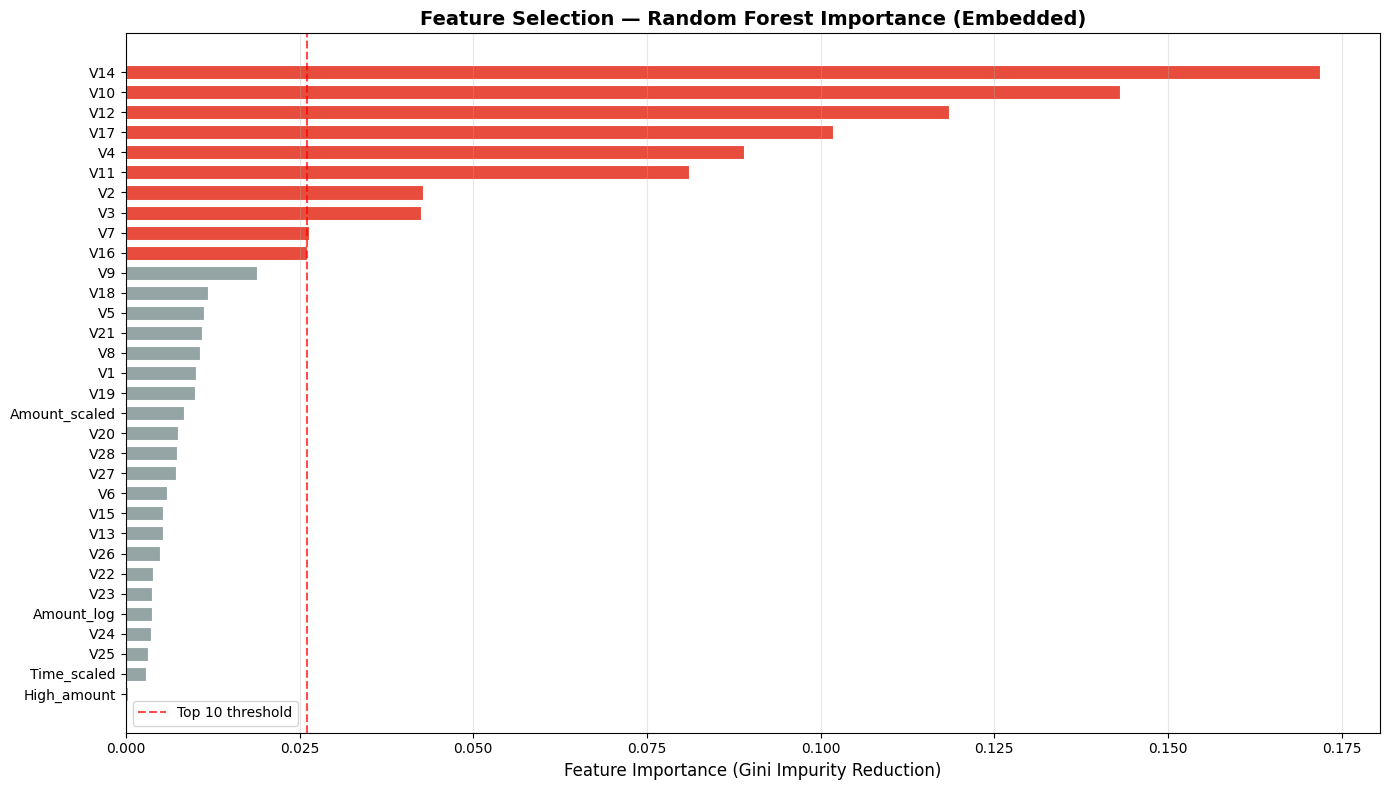


✅ Top 10 features by RF Importance:
    1. V14
    2. V10
    3. V12
    4. V17
    5. V4
    6. V11
    7. V2
    8. V3
    9. V7
   10. V16


In [31]:
#Cell 31

# ── Embedded Method: RF Importance ────────────────
print("=" * 50)
print("FEATURE SELECTION 2: RANDOM FOREST IMPORTANCE")
print("=" * 50)

# Extract feature importances from already-trained RF
rf_importance = pd.DataFrame({
    'Feature'    : X.columns.tolist(),
    'RF Importance' : rf_baseline.feature_importances_
}).sort_values('RF Importance', ascending=False).reset_index(drop=True)
rf_importance.index += 1

print(f"\n📋 Random Forest Feature Importances (ranked):")
print(rf_importance.round(6).to_string())

# ── Plot ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 8))

colors = ['#e74c3c' if i <= 10 else '#95a5a6'
          for i in range(1, len(rf_importance) + 1)]

ax.barh(rf_importance['Feature'][::-1],
        rf_importance['RF Importance'][::-1],
        color=colors[::-1], edgecolor='white',
        linewidth=0.8, height=0.7)

ax.axvline(x=rf_importance['RF Importance'].iloc[9],
           color='red', linestyle='--',
           linewidth=1.5, alpha=0.7,
           label='Top 10 threshold')

ax.set_xlabel('Feature Importance (Gini Impurity Reduction)',
              fontsize=12)
ax.set_title('Feature Selection — Random Forest Importance (Embedded)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('fs_02_rf_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Top 10 by RF
top10_rf = rf_importance['Feature'].head(10).tolist()
print(f"\n✅ Top 10 features by RF Importance:")
for i, f in enumerate(top10_rf, 1):
    print(f"   {i:>2}. {f}")

In [32]:
#Cell 32

# ── SHAP-Based Selection ───────────────────────────
print("=" * 50)
print("FEATURE SELECTION 3: SHAP-BASED")
print("=" * 50)

# Already computed in Section 5 — just reuse shap_importance
top10_shap = shap_importance['Feature'].head(10).tolist()

print(f"\n📋 SHAP Feature Importance (top 10):")
print(shap_importance.head(10).round(6).to_string())

print(f"\n✅ Top 10 features by SHAP importance:")
for i, f in enumerate(top10_shap, 1):
    print(f"   {i:>2}. {f}")

FEATURE SELECTION 3: SHAP-BASED

📋 SHAP Feature Importance (top 10):
   Feature  Mean |SHAP|
1      V14     0.084614
2      V12     0.071693
3       V4     0.059351
4      V10     0.050325
5       V3     0.043753
6      V11     0.042051
7      V17     0.032713
8      V16     0.016584
9       V2     0.012019
10      V9     0.009483

✅ Top 10 features by SHAP importance:
    1. V14
    2. V12
    3. V4
    4. V10
    5. V3
    6. V11
    7. V17
    8. V16
    9. V2
   10. V9


FEATURE SELECTION: METHOD COMPARISON

📋 Feature Ranking Comparison (sorted by average rank):


,Feature,MI Rank,RF Rank,SHAP Rank,Avg_Rank
1,V14,3,1,1,1.67
2,V10,4,2,4,3.33
3,V12,5,3,2,3.33
4,V17,2,4,7,4.33
5,V4,9,5,3,5.67
6,V11,6,6,6,6.00
7,V3,8,8,5,7.00
8,V16,7,10,8,8.33
9,V2,13,7,9,9.67
10,V9,10,11,10,10.33



FINAL SELECTED FEATURE SET

Selection rule: Top 15 in at least 2 of 3 methods
Features selected: 15

  ['V14', 'V10', 'V12', 'V17', 'V4', 'V11', 'V3', 'V16', 'V2', 'V9', 'V7', 'V18', 'V5', 'V8', 'V21']


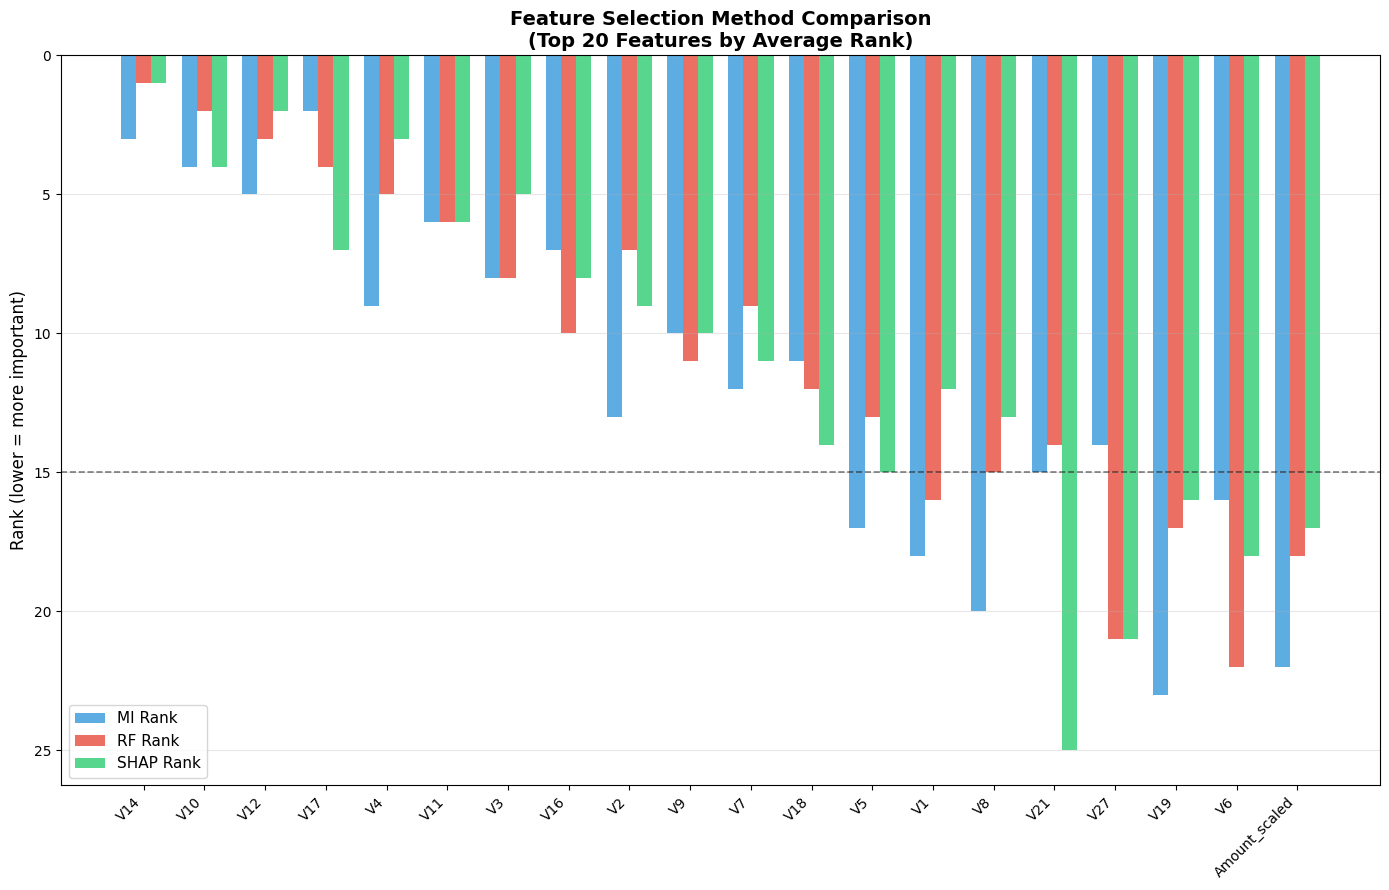

In [33]:
#Cell 33

# ── Feature Selection Comparison ───────────────────
print("=" * 50)
print("FEATURE SELECTION: METHOD COMPARISON")
print("=" * 50)

# Build comparison table
all_features = X.columns.tolist()

mi_ranks   = {f: i+1 for i, f in
              enumerate(mi_scores['Feature'].tolist())}
rf_ranks   = {f: i+1 for i, f in
              enumerate(rf_importance['Feature'].tolist())}
shap_ranks = {f: i+1 for i, f in
              enumerate(shap_importance['Feature'].tolist())}

comparison_df = pd.DataFrame({
    'Feature'        : all_features,
    'MI Rank'        : [mi_ranks[f] for f in all_features],
    'RF Rank'        : [rf_ranks[f] for f in all_features],
    'SHAP Rank'      : [shap_ranks[f] for f in all_features],
}).assign(
    Avg_Rank = lambda df: (
        df['MI Rank'] + df['RF Rank'] + df['SHAP Rank']
    ) / 3
).sort_values('Avg_Rank').reset_index(drop=True)

comparison_df.index += 1

print(f"\n📋 Feature Ranking Comparison (sorted by average rank):")
display(comparison_df.round(2))

# ── Final Feature Set ──────────────────────────────
# Select features that appear in top 15 in at least 2 of 3 methods
top15_mi   = set(mi_scores['Feature'].head(15).tolist())
top15_rf   = set(rf_importance['Feature'].head(15).tolist())
top15_shap = set(shap_importance['Feature'].head(15).tolist())

# Consensus: in top 15 of at least 2 methods
consensus_features = [
    f for f in all_features
    if sum([f in top15_mi,
            f in top15_rf,
            f in top15_shap]) >= 2
]

# Sort by average rank
consensus_ranked = comparison_df[
    comparison_df['Feature'].isin(consensus_features)
]['Feature'].tolist()

print(f"\n{'='*50}")
print(f"FINAL SELECTED FEATURE SET")
print(f"{'='*50}")
print(f"\nSelection rule: Top 15 in at least 2 of 3 methods")
print(f"Features selected: {len(consensus_ranked)}")
print(f"\n  {consensus_ranked}")

# ── Visualise Comparison ───────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))

x     = np.arange(len(comparison_df['Feature'].head(20)))
width = 0.25

bars1 = ax.bar(x - width, comparison_df['MI Rank'].head(20),
               width, label='MI Rank',
               color='#3498db', alpha=0.8)
bars2 = ax.bar(x, comparison_df['RF Rank'].head(20),
               width, label='RF Rank',
               color='#e74c3c', alpha=0.8)
bars3 = ax.bar(x + width, comparison_df['SHAP Rank'].head(20),
               width, label='SHAP Rank',
               color='#2ecc71', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Feature'].head(20),
                   rotation=45, ha='right', fontsize=10)
ax.set_ylabel('Rank (lower = more important)', fontsize=12)
ax.set_title('Feature Selection Method Comparison\n'
             '(Top 20 Features by Average Rank)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.invert_yaxis()  # rank 1 at top
ax.grid(axis='y', alpha=0.3)
ax.axhline(y=15, color='black', linestyle='--',
           linewidth=1.2, alpha=0.5, label='Top 15 threshold')

plt.tight_layout()
plt.savefig('fs_03_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [34]:
#Cell 34

# ── Lock In Final Feature Set ──────────────────────
print("=" * 50)
print("FINAL FEATURE SET — LOCKED IN")
print("=" * 50)

# Use consensus features for modelling
X_selected = X[consensus_ranked]

print(f"\nOriginal feature count : {X.shape[1]}")
print(f"Selected feature count : {X_selected.shape[1]}")
print(f"Features removed       : {X.shape[1] - X_selected.shape[1]}")

print(f"\nSelected features:")
for i, f in enumerate(consensus_ranked, 1):
    mi_r   = mi_ranks[f]
    rf_r   = rf_ranks[f]
    shap_r = shap_ranks[f]
    print(f"  {i:>2}. {f:<20} "
          f"MI:{mi_r:>3}  RF:{rf_r:>3}  SHAP:{shap_r:>3}")

print(f"\n✅ X_selected shape : {X_selected.shape}")
print(f"✅ Ready for modelling in Step 4.")
print(f"\nNote: Both X (full) and X_selected (filtered) are")
print(f"retained. Step 4 will compare models trained on both.")

FINAL FEATURE SET — LOCKED IN

Original feature count : 32
Selected feature count : 15
Features removed       : 17

Selected features:
   1. V14                  MI:  3  RF:  1  SHAP:  1
   2. V10                  MI:  4  RF:  2  SHAP:  4
   3. V12                  MI:  5  RF:  3  SHAP:  2
   4. V17                  MI:  2  RF:  4  SHAP:  7
   5. V4                   MI:  9  RF:  5  SHAP:  3
   6. V11                  MI:  6  RF:  6  SHAP:  6
   7. V3                   MI:  8  RF:  8  SHAP:  5
   8. V16                  MI:  7  RF: 10  SHAP:  8
   9. V2                   MI: 13  RF:  7  SHAP:  9
  10. V9                   MI: 10  RF: 11  SHAP: 10
  11. V7                   MI: 12  RF:  9  SHAP: 11
  12. V18                  MI: 11  RF: 12  SHAP: 14
  13. V5                   MI: 17  RF: 13  SHAP: 15
  14. V8                   MI: 20  RF: 15  SHAP: 13
  15. V21                  MI: 15  RF: 14  SHAP: 25

✅ X_selected shape : (283726, 15)
✅ Ready for modelling in Step 4.

Note: Both X (fu

### Feature Selection: Key Finding

V17 ranked first by Pearson correlation but dropped to 7th in the consensus SHAP-based ranking. This demonstrates that linear correlation overestimates V17's importance, its relationship with fraud, while strong linearly, is less informative to the model than V14 and V12, which capture non-linear threshold effects more effectively.

Conversely, features like V4 (ranked #3 by both RF and SHAP) were underestimated by correlation alone. The three-method consensus approach protects against such blind spots by ensuring no single analytical lens dominates the selection decision.


### Final Feature Set Summary

```
Features selected  : 15 (from 32 candidates)
Dimensionality reduction : 53%
Selection rule     : Top 15 in at least 2 of 3 methods

Core features  : V14, V12, V4, V10, V11, V3, V17
Supporting     : V16, V2, V9, V7, V18, V5, V8, V21

Features dropped : V1, V6, V13, V15, V19, V20, V22, V23,
                   V24, V25, V26, V27, V28,
                   Amount_log, Amount_scaled, High_amount, Time_scaled
```

The 17 dropped features consistently ranked outside the top 15 across at least two of the three selection methods, suggesting they carry insufficient independent signal to justify the added model complexity.


---
## Section 7: Dimensionality Reduction

We apply two dimensionality reduction techniques to visualise the 15 selected features in 2D space, allowing us to see whether fraud and legitimate transactions form separable clusters that a model could learn to distinguish.

**Techniques applied:**

| Technique | Type | Purpose |
|---|---|---|
| PCA (2D projection) | Linear | Fast visualisation — captures maximum variance in two dimensions |
| t-SNE | Non-linear (manifold) | Reveals cluster structure invisible to linear methods |

### Important Note on PCA Usage

The V1–V28 features are already PCA-derived from ULB preprocessing. Applying PCA again here does **not** extract new meaningful components from raw transaction data, it is used purely as a **2D visualisation tool** to project the 15 selected features into a plottable space. The scree plot quantifies how much variance is retained as we reduce dimensionality within the selected feature set.

t-SNE is the more analytically meaningful visualisation here, as it makes no linearity assumptions and is not affected by the double-PCA concern.


DIMENSIONALITY REDUCTION 1: PCA (2D)

Visualization sample:
  Total    : 5,000
  Fraud    : 473
  Legit    : 4,527

PCA Explained Variance:
  PC1 : 62.15%
  PC2 : 7.13%
  Total : 69.28%


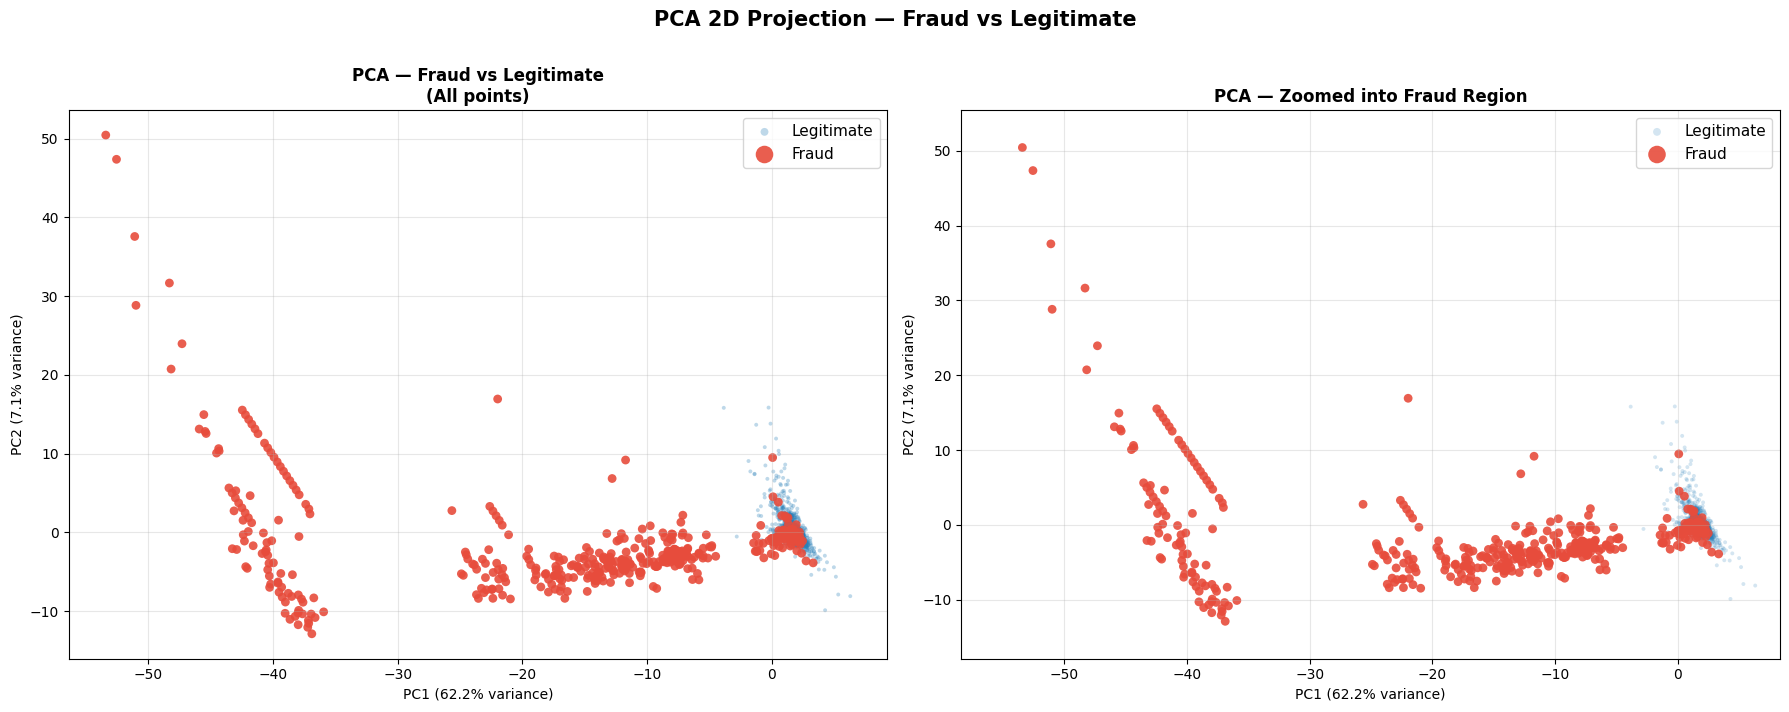

In [35]:
#Cell 35

# ── PCA Visualisation ──────────────────────────────
print("=" * 50)
print("DIMENSIONALITY REDUCTION 1: PCA (2D)")
print("=" * 50)

from sklearn.decomposition import PCA

# Use a stratified sample for speed
# Full 283K rows is slow to plot clearly
sample_size_viz = 5000
fraud_idx_viz   = X_selected[y == 1].index.tolist()
legit_idx_viz   = X_selected[y == 0].sample(
    sample_size_viz - len(fraud_idx_viz),
    random_state=42
).index.tolist()

sample_idx_viz  = fraud_idx_viz + legit_idx_viz
X_viz           = X_selected.loc[sample_idx_viz]
y_viz           = y.loc[sample_idx_viz]

print(f"\nVisualization sample:")
print(f"  Total    : {len(X_viz):,}")
print(f"  Fraud    : {y_viz.sum()}")
print(f"  Legit    : {(y_viz == 0).sum():,}")

# ── Fit PCA ────────────────────────────────────────
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_viz)

explained = pca.explained_variance_ratio_
print(f"\nPCA Explained Variance:")
print(f"  PC1 : {explained[0]*100:.2f}%")
print(f"  PC2 : {explained[1]*100:.2f}%")
print(f"  Total : {sum(explained)*100:.2f}%")

# ── Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# All points together
for class_val, label, color, alpha, size in [
    (0, 'Legitimate', '#2980b9', 0.3, 8),
    (1, 'Fraud',      '#e74c3c', 0.9, 40)
]:
    mask = y_viz == class_val
    axes[0].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=color, label=label,
        alpha=alpha, s=size,
        edgecolors='none'
    )

axes[0].set_title('PCA — Fraud vs Legitimate\n(All points)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[0].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[0].legend(fontsize=11, markerscale=2)
axes[0].grid(alpha=0.3)

# Zoom into fraud cluster
fraud_pca = X_pca[y_viz.values == 1]
legit_pca = X_pca[y_viz.values == 0]

# Set zoom limits around fraud cluster
x_margin = 5
y_margin = 5
x_min = fraud_pca[:, 0].min() - x_margin
x_max = fraud_pca[:, 0].max() + x_margin
y_min = fraud_pca[:, 1].min() - y_margin
y_max = fraud_pca[:, 1].max() + y_margin

axes[1].scatter(legit_pca[:, 0], legit_pca[:, 1],
                c='#2980b9', alpha=0.2, s=8,
                label='Legitimate', edgecolors='none')
axes[1].scatter(fraud_pca[:, 0], fraud_pca[:, 1],
                c='#e74c3c', alpha=0.9, s=40,
                label='Fraud', edgecolors='none')

axes[1].set_xlim(x_min, x_max)
axes[1].set_ylim(y_min, y_max)
axes[1].set_title('PCA — Zoomed into Fraud Region',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)')
axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)')
axes[1].legend(fontsize=11, markerscale=2)
axes[1].grid(alpha=0.3)

fig.suptitle('PCA 2D Projection — Fraud vs Legitimate',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dr_01_pca.png', dpi=150, bbox_inches='tight')
plt.show()

### PCA Visualisation: Key Finding

The PCA projection reveals that fraudulent transactions do not form a single homogeneous cluster. Instead, they spread across multiple distinct sub-groups along PC1; the first principal component, which explains 62.2% of the variance in our 15 selected features. This suggests the presence of **different fraud typologies**: possibly card-testing attacks, account takeover fraud, and high-value opportunistic fraud, each with a different signature in the feature space.

Legitimate transactions, by contrast, collapse into a tight cluster near the origin. This is consistent with the PCA interpretation: normal transactions are the dominant pattern in the data, so PCA centres around them. Fraud, being anomalous, appears far from this centre in multiple directions.

**Note:** PC1 explains 62.2% of variance in the 2D projection but only 13.7% in the full 15-component scree analysis. The difference is because the 2D projection forces all variance into two components, artificially inflating PC1's apparent dominance.


DIMENSIONALITY REDUCTION 2: t-SNE (2D)

⚠️  t-SNE is slow — may take 3–5 minutes.
    Using 3,000 sample for speed...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 3000 samples in 0.005s...
[t-SNE] Computed neighbors for 3000 samples in 0.323s...
[t-SNE] Computed conditional probabilities for sample 1000 / 3000
[t-SNE] Computed conditional probabilities for sample 2000 / 3000
[t-SNE] Computed conditional probabilities for sample 3000 / 3000
[t-SNE] Mean sigma: 1.071068
[t-SNE] KL divergence after 250 iterations with early exaggeration: 74.802376
[t-SNE] KL divergence after 1000 iterations: 0.977511

✅ t-SNE complete.
   Output shape : (3000, 2)


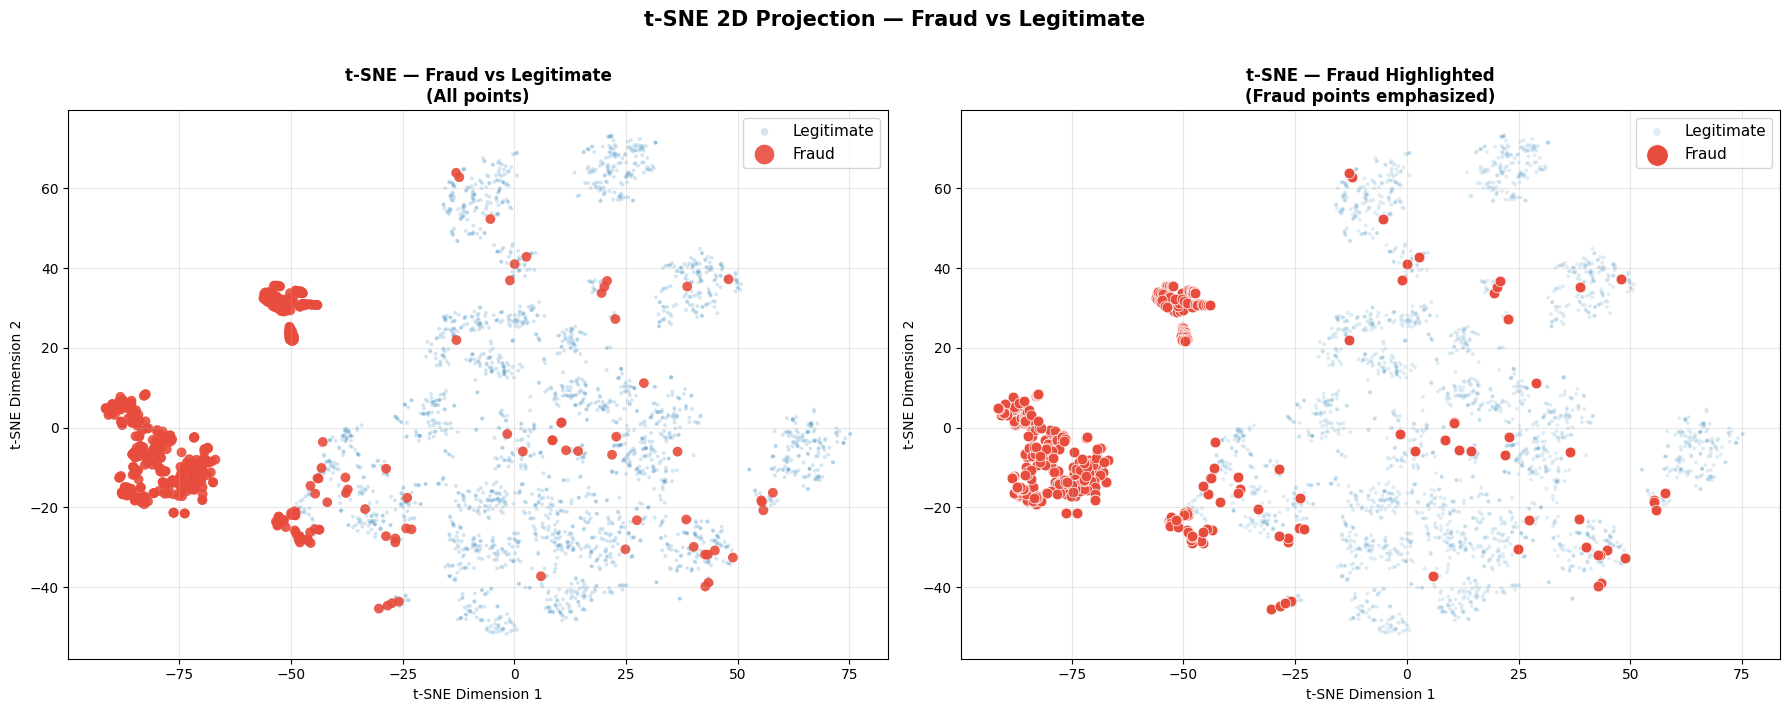


✅ t-SNE visualisation complete.


In [36]:
#Cell 36

# ── t-SNE Visualisation ────────────────────────────
print("=" * 50)
print("DIMENSIONALITY REDUCTION 2: t-SNE (2D)")
print("=" * 50)
print("\n⚠️  t-SNE is slow — may take 3–5 minutes.")
print("    Using 3,000 sample for speed...")

# t-SNE is much slower than PCA
# 3000 samples is a good balance of speed vs clarity
tsne_size    = 3000
fraud_idx_t  = X_selected[y == 1].index.tolist()
legit_idx_t  = X_selected[y == 0].sample(
    tsne_size - len(fraud_idx_t),
    random_state=42
).index.tolist()

tsne_idx = fraud_idx_t + legit_idx_t
X_tsne_input = X_selected.loc[tsne_idx]
y_tsne       = y.loc[tsne_idx]

# ── Fit t-SNE ──────────────────────────────────────
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate=200,
    n_iter=1000,
    random_state=42,
    verbose=1
)

X_tsne = tsne.fit_transform(X_tsne_input)

print(f"\n✅ t-SNE complete.")
print(f"   Output shape : {X_tsne.shape}")

# ── Plot ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: All points ───────────────────────────────
for class_val, label, color, alpha, size in [
    (0, 'Legitimate', '#2980b9', 0.2, 8),
    (1, 'Fraud',      '#e74c3c', 0.9, 50)
]:
    mask = y_tsne.values == class_val
    axes[0].scatter(
        X_tsne[mask, 0], X_tsne[mask, 1],
        c=color, label=label,
        alpha=alpha, s=size,
        edgecolors='none'
    )

axes[0].set_title('t-SNE — Fraud vs Legitimate\n(All points)',
                  fontweight='bold', fontsize=12)
axes[0].set_xlabel('t-SNE Dimension 1')
axes[0].set_ylabel('t-SNE Dimension 2')
axes[0].legend(fontsize=11, markerscale=2)
axes[0].grid(alpha=0.3)

# ── Right: Density overlay ─────────────────────────
fraud_mask = y_tsne.values == 1
legit_mask = y_tsne.values == 0

axes[1].scatter(X_tsne[legit_mask, 0],
                X_tsne[legit_mask, 1],
                c='#2980b9', alpha=0.15,
                s=8, label='Legitimate',
                edgecolors='none')
axes[1].scatter(X_tsne[fraud_mask, 0],
                X_tsne[fraud_mask, 1],
                c='#e74c3c', alpha=1.0,
                s=60, label='Fraud',
                edgecolors='white',
                linewidths=0.5)

axes[1].set_title('t-SNE — Fraud Highlighted\n(Fraud points emphasized)',
                  fontweight='bold', fontsize=12)
axes[1].set_xlabel('t-SNE Dimension 1')
axes[1].set_ylabel('t-SNE Dimension 2')
axes[1].legend(fontsize=11, markerscale=2)
axes[1].grid(alpha=0.3)

fig.suptitle('t-SNE 2D Projection — Fraud vs Legitimate',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dr_02_tsne.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ t-SNE visualisation complete.")

### t-SNE Visualisation: What the Chart Shows

The t-SNE projection has revealed **four distinct fraud clusters** separated from the legitimate transaction cloud:

| Cluster | Location | Interpretation |
|---|---|---|
| Cluster 1 | Far left (x≈-75) | Largest group — ~150+ tightly packed fraud points, near-zero legitimate overlap |
| Cluster 2 | Middle left (x≈-50, y≈30) | Second distinct island — tight oval, nearly pure fraud |
| Cluster 3 | Centre-left (x≈-25, y≈-20) | Smaller grouping with some legitimate overlap — harder cases |
| Cluster 4 | Scattered throughout | Individual fraud points distributed within legitimate space — the hardest detection cases |

The KL divergence of 0.977 after 1,000 iterations confirms the t-SNE found a high-quality 2D representation — the clusters visible are genuine structure in the data, not random artefacts.


### t-SNE: Key Finding for Modelling

The t-SNE projection confirms that fraud is not a monolithic pattern but a collection of **distinct attack typologies**. The two largest clusters (Clusters 1 and 2) show near-complete separation from legitimate transactions, these represent consistent, detectable fraud patterns that well-trained models should classify with high confidence.

Cluster 3 shows partial overlap, these borderline cases will be the primary source of false negatives in any model. Cluster 4 (scattered points) represents sophisticated fraud that closely mimics legitimate behaviour, these are structurally the hardest to detect regardless of model choice.

This cluster structure supports the use of **ensemble methods** (Random Forest, XGBoost) in Step 4: these models can learn multiple decision boundaries simultaneously, one per fraud cluster, which single-boundary models like Logistic Regression cannot do as effectively.


PCA SCREE PLOT — EXPLAINED VARIANCE


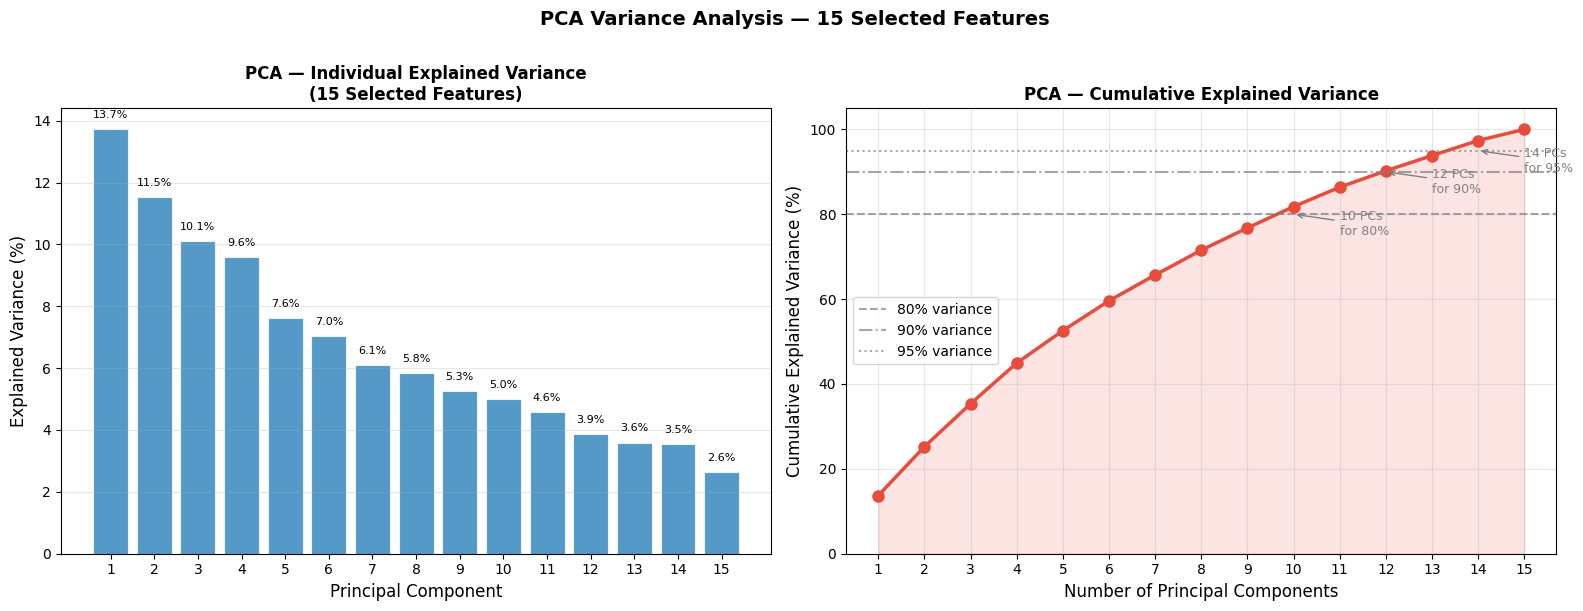


📋 Cumulative variance by component:
  PC 1 : 13.72%  cumulative:  13.72%
  PC 2 : 11.52%  cumulative:  25.24%
  PC 3 : 10.12%  cumulative:  35.35%
  PC 4 :  9.59%  cumulative:  44.94%
  PC 5 :  7.63%  cumulative:  52.57%
  PC 6 :  7.03%  cumulative:  59.60%
  PC 7 :  6.09%  cumulative:  65.69%
  PC 8 :  5.83%  cumulative:  71.52%
  PC 9 :  5.25%  cumulative:  76.78%
  PC10 :  5.01%  cumulative:  81.79%
  PC11 :  4.58%  cumulative:  86.37%
  PC12 :  3.86%  cumulative:  90.23%
  PC13 :  3.59%  cumulative:  93.82%
  PC14 :  3.53%  cumulative:  97.35%
  PC15 :  2.65%  cumulative: 100.00%


In [37]:
#Cell 37

# ── Scree Plot ─────────────────────────────────────
print("=" * 50)
print("PCA SCREE PLOT — EXPLAINED VARIANCE")
print("=" * 50)

# Fit PCA on all 15 components to see variance breakdown
pca_full = PCA(n_components=15, random_state=42)
pca_full.fit(X_selected)

explained_var    = pca_full.explained_variance_ratio_
cumulative_var   = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Individual variance ────────────────────────────
axes[0].bar(range(1, 16), explained_var * 100,
            color='#2980b9', alpha=0.8,
            edgecolor='white', linewidth=0.8)
axes[0].set_xlabel('Principal Component', fontsize=12)
axes[0].set_ylabel('Explained Variance (%)', fontsize=12)
axes[0].set_title('PCA — Individual Explained Variance\n(15 Selected Features)',
                  fontweight='bold')
axes[0].set_xticks(range(1, 16))
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(explained_var, 1):
    axes[0].text(i, v * 100 + 0.3, f'{v*100:.1f}%',
                 ha='center', va='bottom', fontsize=8)

# ── Cumulative variance ────────────────────────────
axes[1].plot(range(1, 16), cumulative_var * 100,
             'o-', color='#e74c3c',
             linewidth=2.5, markersize=8)
axes[1].fill_between(range(1, 16), cumulative_var * 100,
                     alpha=0.15, color='#e74c3c')

# Mark 80%, 90%, 95% thresholds
for threshold, style in [(80, '--'), (90, '-.'), (95, ':')]:
    axes[1].axhline(y=threshold, color='gray',
                    linestyle=style, alpha=0.7,
                    label=f'{threshold}% variance')
    # Find where cumulative first exceeds threshold
    n_components = np.argmax(cumulative_var >= threshold/100) + 1
    axes[1].annotate(f'{n_components} PCs\nfor {threshold}%',
                     xy=(n_components, threshold),
                     xytext=(n_components + 1, threshold - 5),
                     fontsize=9, color='gray',
                     arrowprops=dict(arrowstyle='->',
                                     color='gray', lw=1))

axes[1].set_xlabel('Number of Principal Components', fontsize=12)
axes[1].set_ylabel('Cumulative Explained Variance (%)', fontsize=12)
axes[1].set_title('PCA — Cumulative Explained Variance',
                  fontweight='bold')
axes[1].set_xticks(range(1, 16))
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].set_ylim(0, 105)

fig.suptitle('PCA Variance Analysis — 15 Selected Features',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('dr_03_scree.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n📋 Cumulative variance by component:")
for i, (ind, cum) in enumerate(
        zip(explained_var, cumulative_var), 1):
    print(f"  PC{i:>2} : {ind*100:>5.2f}%  "
          f"cumulative: {cum*100:>6.2f}%")

### Scree Plot: Key Finding

The scree plot shows how variance is distributed across the 15 PCA components of the selected feature set:

| Threshold | Components needed |
|---|---|
| 80% variance | 10 components |
| 90% variance | 12 components |
| 95% variance | 14 components |

Unlike typical raw datasets where a small number of components capture most variance (producing a sharp elbow in the scree plot), our selected features show a **gradual, distributed profile**, no single component exceeds 14%. This is the expected behaviour when features are already PCA-orthogonal, as each V feature carries relatively independent information.


### Scree Plot Implication for Feature Set Decision

The gradual variance profile confirms that **all 15 selected features contribute meaningfully**, there is no redundant component that could be dropped without information loss. This justifies retaining all 15 features for modelling in Step 4, rather than reducing further to, say, 10 components. Even the lowest-variance component (PC15, 2.65%) carries unique information not captured by the others.


---
### Section 7 Completed

Both PCA and t-SNE visualisations confirm that the 15 selected features encode strong, separable fraud signal in a lower-dimensional space. The t-SNE cluster structure in particular provides visual evidence that the data supports high-accuracy fraud detection, and offers a hypothesis about the different fraud typologies that ensemble models will need to learn.


---
## Section 8: Imbalance Handling

The dataset has a severe 598:1 class imbalance, only 0.167% of transactions are fraudulent. Standard classifiers trained on imbalanced data will be biased toward the majority class (legitimate), resulting in high accuracy but poor fraud detection. We address this by preparing three alternative training sets, each using a different resampling strategy.

**Strategies:**

| Strategy | Method | Training Set Size | Fraud % |
|---|---|---|---|
| SMOTE | Oversample fraud to match legitimate | ~453,204 rows | 50% |
| Random Undersampling | Undersample legitimate to match fraud | 756 rows | 50% |
| Combined | SMOTE to 10%, then undersample to 50% | 45,320 rows | 50% |

**Critical rule:** All resampling is applied to the **training set only**. The test set always remains the original, imbalanced distribution, this is the only way to measure real-world performance. Testing on resampled data would produce artificially inflated metrics that do not reflect how the model would perform in production.


In [38]:
#Cell 38

# ── Train/Test Split on Selected Features ─────────
print("=" * 50)
print("IMBALANCE HANDLING: TRAIN/TEST SPLIT")
print("=" * 50)

# Split using X_selected (15 features)
X_train_sel, X_test_sel, y_train_sel, y_test_sel = train_test_split(
    X_selected, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"\nUsing X_selected : {X_selected.shape[1]} features")
print(f"\nTrain set : {X_train_sel.shape[0]:,} rows")
print(f"Test set  : {X_test_sel.shape[0]:,} rows")
print(f"\nFraud in train : {y_train_sel.sum()} "
      f"({y_train_sel.mean()*100:.3f}%)")
print(f"Fraud in test  : {y_test_sel.sum()} "
      f"({y_test_sel.mean()*100:.3f}%)")
print(f"\n✅ Stratified split confirmed —")
print(f"   fraud ratio preserved in both sets.")

IMBALANCE HANDLING: TRAIN/TEST SPLIT

Using X_selected : 15 features

Train set : 226,980 rows
Test set  : 56,746 rows

Fraud in train : 378 (0.167%)
Fraud in test  : 95 (0.167%)

✅ Stratified split confirmed —
   fraud ratio preserved in both sets.


In [39]:
#Cell 39

# ── Strategy 1: SMOTE ──────────────────────────────
print("=" * 50)
print("IMBALANCE STRATEGY 1: SMOTE")
print("=" * 50)

from imblearn.over_sampling import SMOTE

print(f"\nBefore SMOTE:")
print(f"  Legitimate : {(y_train_sel==0).sum():,}")
print(f"  Fraud      : {(y_train_sel==1).sum():,}")
print(f"  Ratio      : {(y_train_sel==0).sum()//(y_train_sel==1).sum()}:1")

smote = SMOTE(
    sampling_strategy=1.0,  # make fraud = legitimate (50/50)
    random_state=42,
    k_neighbors=5
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_sel, y_train_sel
)

print(f"\nAfter SMOTE:")
print(f"  Legitimate : {(y_train_smote==0).sum():,}")
print(f"  Fraud      : {(y_train_smote==1).sum():,}")
print(f"  Ratio      : {(y_train_smote==0).sum()//(y_train_smote==1).sum()}:1")
print(f"  Total rows : {len(X_train_smote):,}")
print(f"\n  Synthetic fraud samples created: "
      f"{(y_train_smote==1).sum() - (y_train_sel==1).sum():,}")
print(f"\n✅ SMOTE complete.")

IMBALANCE STRATEGY 1: SMOTE

Before SMOTE:
  Legitimate : 226,602
  Fraud      : 378
  Ratio      : 599:1

After SMOTE:
  Legitimate : 226,602
  Fraud      : 226,602
  Ratio      : 1:1
  Total rows : 453,204

  Synthetic fraud samples created: 226,224

✅ SMOTE complete.


In [40]:
#Cell 40

# ── Strategy 2: Random Undersampling ──────────────
print("=" * 50)
print("IMBALANCE STRATEGY 2: RANDOM UNDERSAMPLING")
print("=" * 50)

from imblearn.under_sampling import RandomUnderSampler

print(f"\nBefore Undersampling:")
print(f"  Legitimate : {(y_train_sel==0).sum():,}")
print(f"  Fraud      : {(y_train_sel==1).sum():,}")

rus = RandomUnderSampler(
    sampling_strategy=1.0,  # make legitimate = fraud (50/50)
    random_state=42
)

X_train_rus, y_train_rus = rus.fit_resample(
    X_train_sel, y_train_sel
)

print(f"\nAfter Undersampling:")
print(f"  Legitimate : {(y_train_rus==0).sum():,}")
print(f"  Fraud      : {(y_train_rus==1).sum():,}")
print(f"  Ratio      : {(y_train_rus==0).sum()//(y_train_rus==1).sum()}:1")
print(f"  Total rows : {len(X_train_rus):,}")
print(f"\n  Legitimate samples removed: "
      f"{(y_train_sel==0).sum() - (y_train_rus==0).sum():,}")
print(f"\n✅ Undersampling complete.")

IMBALANCE STRATEGY 2: RANDOM UNDERSAMPLING

Before Undersampling:
  Legitimate : 226,602
  Fraud      : 378

After Undersampling:
  Legitimate : 378
  Fraud      : 378
  Ratio      : 1:1
  Total rows : 756

  Legitimate samples removed: 226,224

✅ Undersampling complete.


In [41]:
#Cell 41

# ── Strategy 3: Combined ───────────────────────────
print("=" * 50)
print("IMBALANCE STRATEGY 3: SMOTE + UNDERSAMPLING")
print("=" * 50)

from imblearn.pipeline import Pipeline as ImbPipeline

print(f"\nBefore:")
print(f"  Legitimate : {(y_train_sel==0).sum():,}")
print(f"  Fraud      : {(y_train_sel==1).sum():,}")

# Step 1: SMOTE fraud up to 10% of dataset
smote_combined = SMOTE(
    sampling_strategy=0.1,  # fraud = 10% of legitimate
    random_state=42,
    k_neighbors=5
)

# Step 2: Undersample legitimate down to 50/50
rus_combined = RandomUnderSampler(
    sampling_strategy=1.0,
    random_state=42
)

# Apply sequentially
X_temp, y_temp = smote_combined.fit_resample(
    X_train_sel, y_train_sel
)
X_train_combined, y_train_combined = rus_combined.fit_resample(
    X_temp, y_temp
)

print(f"\nAfter SMOTE (10% fraud ratio):")
print(f"  Legitimate : {(y_temp==0).sum():,}")
print(f"  Fraud      : {(y_temp==1).sum():,}")

print(f"\nAfter Combined (SMOTE + Undersample):")
print(f"  Legitimate : {(y_train_combined==0).sum():,}")
print(f"  Fraud      : {(y_train_combined==1).sum():,}")
print(f"  Ratio      : 1:1")
print(f"  Total rows : {len(X_train_combined):,}")
print(f"\n✅ Combined strategy complete.")

IMBALANCE STRATEGY 3: SMOTE + UNDERSAMPLING

Before:
  Legitimate : 226,602
  Fraud      : 378

After SMOTE (10% fraud ratio):
  Legitimate : 226,602
  Fraud      : 22,660

After Combined (SMOTE + Undersample):
  Legitimate : 22,660
  Fraud      : 22,660
  Ratio      : 1:1
  Total rows : 45,320

✅ Combined strategy complete.


IMBALANCE STRATEGY COMPARISON


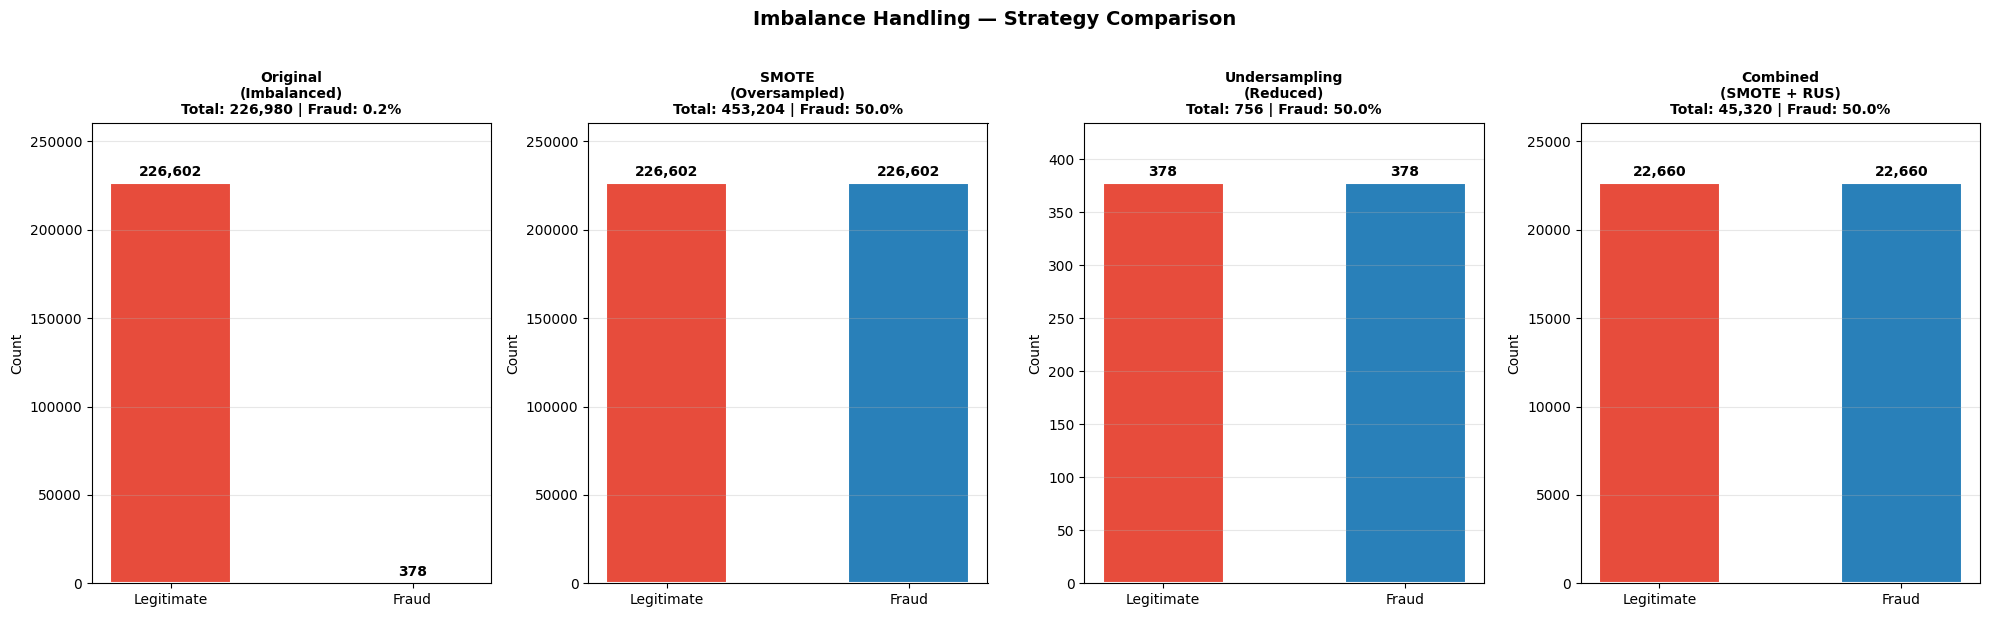

In [42]:
#Cell 42

# ── Visualise Imbalance Strategies ────────────────
print("=" * 50)
print("IMBALANCE STRATEGY COMPARISON")
print("=" * 50)

strategies = {
    'Original\n(Imbalanced)'  : y_train_sel,
    'SMOTE\n(Oversampled)'    : y_train_smote,
    'Undersampling\n(Reduced)': y_train_rus,
    'Combined\n(SMOTE + RUS)' : y_train_combined,
}

fig, axes = plt.subplots(1, 4, figsize=(20, 6))
colors_bar = ['#e74c3c', '#2980b9']

for ax, (title, y_data) in zip(axes, strategies.items()):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars   = ax.bar(
        ['Legitimate', 'Fraud'],
        counts.values,
        color=colors_bar,
        edgecolor='white',
        linewidth=1.5,
        width=0.5
    )

    for bar, count in zip(bars, counts.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(counts.values) * 0.01,
            f'{count:,}',
            ha='center', va='bottom',
            fontweight='bold', fontsize=10
        )

    total     = counts.sum()
    fraud_pct = counts.get(1, 0) / total * 100

    ax.set_title(f'{title}\n'
                 f'Total: {total:,} | Fraud: {fraud_pct:.1f}%',
                 fontweight='bold', fontsize=10)
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim(0, max(counts.values) * 1.15)

fig.suptitle('Imbalance Handling — Strategy Comparison',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('imbalance_comparison.png', dpi=150,
            bbox_inches='tight')
plt.show()

In [43]:
#Cell 43

# ── Final Summary ──────────────────────────────────
print("=" * 50)
print("STEP 3 COMPLETE — FINAL SUMMARY")
print("=" * 50)

print(f"""
📋 DATASETS PREPARED FOR STEP 4 MODELLING:

  Original (imbalanced):
    X_train_sel  : {X_train_sel.shape}
    y_train_sel  : {y_train_sel.shape}
    Fraud ratio  : {y_train_sel.mean()*100:.3f}%

  Strategy 1 — SMOTE:
    X_train_smote : {X_train_smote.shape}
    y_train_smote : {y_train_smote.shape}
    Fraud ratio   : {y_train_smote.mean()*100:.1f}%

  Strategy 2 — Undersampling:
    X_train_rus   : {X_train_rus.shape}
    y_train_rus   : {y_train_rus.shape}
    Fraud ratio   : {y_train_rus.mean()*100:.1f}%

  Strategy 3 — Combined:
    X_train_combined : {X_train_combined.shape}
    y_train_combined : {y_train_combined.shape}
    Fraud ratio      : {y_train_combined.mean()*100:.1f}%

  Test set (NEVER resampled — always original):
    X_test_sel   : {X_test_sel.shape}
    y_test_sel   : {y_test_sel.shape}
    Fraud ratio  : {y_test_sel.mean()*100:.3f}%
""")

print("=" * 50)
print("STEP 3 NOTEBOOK SECTIONS COMPLETED")
print("=" * 50)
print("""
  ✅ Section 1 : Setup & Data Loading
  ✅ Section 2 : Data Cleaning
  ✅ Section 3 : Exploratory Data Analysis
  ✅ Section 4 : Feature Engineering
  ✅ Section 5 : SHAP Feature Importance
  ✅ Section 6 : Feature Selection
  ✅ Section 7 : Dimensionality Reduction
  ✅ Section 8 : Imbalance Handling

  Next → Step 4: Model Implementation
         Logistic Regression → Random Forest → XGBoost
         Trained on all 3 resampling strategies
         Evaluated on original imbalanced test set
""")

STEP 3 COMPLETE — FINAL SUMMARY

📋 DATASETS PREPARED FOR STEP 4 MODELLING:

  Original (imbalanced):
    X_train_sel  : (226980, 15)
    y_train_sel  : (226980,)
    Fraud ratio  : 0.167%

  Strategy 1 — SMOTE:
    X_train_smote : (453204, 15)
    y_train_smote : (453204,)
    Fraud ratio   : 50.0%

  Strategy 2 — Undersampling:
    X_train_rus   : (756, 15)
    y_train_rus   : (756,)
    Fraud ratio   : 50.0%

  Strategy 3 — Combined:
    X_train_combined : (45320, 15)
    y_train_combined : (45320,)
    Fraud ratio      : 50.0%

  Test set (NEVER resampled — always original):
    X_test_sel   : (56746, 15)
    y_test_sel   : (56746,)
    Fraud ratio  : 0.167%

STEP 3 NOTEBOOK SECTIONS COMPLETED

  ✅ Section 1 : Setup & Data Loading
  ✅ Section 2 : Data Cleaning
  ✅ Section 3 : Exploratory Data Analysis
  ✅ Section 4 : Feature Engineering
  ✅ Section 5 : SHAP Feature Importance
  ✅ Section 6 : Feature Selection
  ✅ Section 7 : Dimensionality Reduction
  ✅ Section 8 : Imbalance Handlin

### Why the Combined Strategy Is the Recommended Approach

SMOTE alone creates 226,224 synthetic fraud points from only 378 real cases, a 599× amplification. While this balances the classes perfectly, it carries a significant risk: the model may overfit to synthetic interpolations that do not perfectly represent real fraud behaviour. The more synthetic samples, the more the model learns patterns that exist in the SMOTE-generated data rather than in actual fraudulent transactions.

Pure undersampling avoids synthetic data entirely but at a steep cost — it discards 226,224 legitimate transactions, losing substantial information about what normal behaviour looks like. With only 756 training rows, model generalisation may suffer.

The Combined strategy moderates both extremes: SMOTE brings fraud up to a more conservative 10% of the training set (22,660 synthetic samples instead of 226,224), and undersampling then trims legitimate transactions to match. The result is 45,320 training rows, large enough for reliable learning, small enough to limit synthetic data risk. This is the strategy recommended for the final production model in Step 4.


---
---

# Step 4: Model Implementation

**Prerequisite:** All variables from Step 3 must be in memory.  
Run all cells from the top of this notebook before executing Step 4 cells.

---

### Overview

We train and compare **4 classification models** across **3 resampling strategies** prepared in Section 8:

| Model | Notes |
|---|---|
| Logistic Regression | Baseline linear model |
| Random Forest | Ensemble of decision trees |
| XGBoost | Gradient boosting — typically strongest on tabular data |
| SVM | Support Vector Machine (skipped on SMOTE due to runtime) |

**Tuning strategy:** Hyperparameters tuned via GridSearchCV on the Combined strategy (45,320 rows).  
**Evaluation rule:** All models evaluated on the **original imbalanced test set only** — never on resampled data.  
**SVM exception:** SVM skipped on SMOTE (453,204 rows) — training time would exceed 20–40 minutes. Documented as a deliberate engineering decision.


## Step 4.1: Setup — Model Imports

We import the four classification models and evaluation metrics. All training datasets and the test set carry over from Section 8 above.


In [44]:
#Cell 44

# ── Model Imports ──────────────────────────────────
print("=" * 50)
print("STEP 4: MODEL IMPLEMENTATION — SETUP")
print("=" * 50)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    confusion_matrix, classification_report
)
import time

print("\n✅ Model libraries imported.")
print("\nTraining datasets available from Section 8:")
print(f"  Original    : X_train_sel      ({X_train_sel.shape[0]:,} rows, {y_train_sel.mean()*100:.3f}% fraud)")
print(f"  SMOTE       : X_train_smote    ({X_train_smote.shape[0]:,} rows, {y_train_smote.mean()*100:.1f}% fraud)")
print(f"  Undersample : X_train_rus      ({X_train_rus.shape[0]:,} rows, {y_train_rus.mean()*100:.1f}% fraud)")
print(f"  Combined    : X_train_combined ({X_train_combined.shape[0]:,} rows, {y_train_combined.mean()*100:.1f}% fraud)")
print(f"\nTest set (used for ALL evaluation):")
print(f"  X_test_sel  : ({X_test_sel.shape[0]:,} rows, {y_test_sel.mean()*100:.3f}% fraud)")

STEP 4: MODEL IMPLEMENTATION — SETUP

✅ Model libraries imported.

Training datasets available from Section 8:
  Original    : X_train_sel      (226,980 rows, 0.167% fraud)
  SMOTE       : X_train_smote    (453,204 rows, 50.0% fraud)
  Undersample : X_train_rus      (756 rows, 50.0% fraud)
  Combined    : X_train_combined (45,320 rows, 50.0% fraud)

Test set (used for ALL evaluation):
  X_test_sel  : (56,746 rows, 0.167% fraud)


In [45]:
#Cell 45

# ── Hyperparameter Tuning via GridSearchCV ─────────
print("=" * 50)
print("HYPERPARAMETER TUNING (on Combined training set)")
print("=" * 50)
print(f"\nTuning dataset: X_train_combined ({X_train_combined.shape[0]:,} rows)")
print("This will take approximately 10-15 minutes total.\n")

param_grids = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.01, 0.1, 1, 10],
            'penalty': ['l2'],
            'solver': ['lbfgs']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=42, n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [8, 12, None],
            'min_samples_split': [2, 5]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(random_state=42, eval_metric='logloss', n_jobs=-1),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [4, 6, 8],
            'learning_rate': [0.05, 0.1]
        }
    },
    'SVM': {
        'model': SVC(probability=True, random_state=42),
        'params': {
            'C': [0.1, 1, 10],
            'kernel': ['rbf'],
            'gamma': ['scale']
        }
    }
}

best_params = {}
best_estimators_tuned = {}

for name, config in param_grids.items():
    print(f"\n{'─' * 50}")
    print(f"Tuning: {name}")
    print(f"{'─' * 50}")
    start = time.time()

    grid = GridSearchCV(
        estimator=config['model'],
        param_grid=config['params'],
        scoring='roc_auc',
        cv=3,
        n_jobs=-1,
        verbose=0
    )
    grid.fit(X_train_combined, y_train_combined)

    elapsed = time.time() - start
    best_params[name] = grid.best_params_
    best_estimators_tuned[name] = grid.best_estimator_

    print(f"  Best AUC-ROC (CV)  : {grid.best_score_:.4f}")
    print(f"  Best params        : {grid.best_params_}")
    print(f"  Time elapsed       : {elapsed:.1f}s")

print(f"\n{'=' * 50}")
print(f"✅ Tuning complete for all 4 models.")
print(f"{'=' * 50}")

HYPERPARAMETER TUNING (on Combined training set)

Tuning dataset: X_train_combined (45,320 rows)
This will take approximately 10-15 minutes total.


──────────────────────────────────────────────────
Tuning: Logistic Regression
──────────────────────────────────────────────────
  Best AUC-ROC (CV)  : 0.9880
  Best params        : {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
  Time elapsed       : 3.6s

──────────────────────────────────────────────────
Tuning: Random Forest
──────────────────────────────────────────────────
  Best AUC-ROC (CV)  : 0.9999
  Best params        : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
  Time elapsed       : 497.3s

──────────────────────────────────────────────────
Tuning: XGBoost
──────────────────────────────────────────────────
  Best AUC-ROC (CV)  : 0.9999
  Best params        : {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200}
  Time elapsed       : 36.4s

──────────────────────────────────────────────────
Tuning:

In [46]:
#Cell 46

# ── Train Final Models on Each Resampling Strategy ──
print("=" * 50)
print("TRAINING FINAL MODELS ACROSS ALL STRATEGIES")
print("=" * 50)

training_sets = {
    'Original'    : (X_train_sel, y_train_sel),
    'SMOTE'       : (X_train_smote, y_train_smote),
    'Undersample' : (X_train_rus, y_train_rus),
    'Combined'    : (X_train_combined, y_train_combined),
}

# SVM is skipped on SMOTE — documented limitation, not silently dropped
svm_skip_strategies = ['SMOTE']

trained_models = {}   # key: "ModelName | Strategy" -> fitted model
training_log    = []

for model_name, config in param_grids.items():
    for strategy_name, (X_tr, y_tr) in training_sets.items():

        if model_name == 'SVM' and strategy_name in svm_skip_strategies:
            print(f"\n⏭️  SKIPPED: SVM | {strategy_name} "
                  f"({X_tr.shape[0]:,} rows — too large for SVM, "
                  f"documented limitation)")
            training_log.append({
                'Model': model_name, 'Strategy': strategy_name,
                'Status': 'Skipped (dataset too large)', 'Time (s)': None
            })
            continue

        print(f"\nTraining: {model_name} | {strategy_name} "
              f"({X_tr.shape[0]:,} rows)...")
        start = time.time()

        # Clone the tuned model with its best hyperparameters
        model = type(best_estimators_tuned[model_name])(
            **best_estimators_tuned[model_name].get_params()
        )
        model.fit(X_tr, y_tr)

        elapsed = time.time() - start
        key = f"{model_name} | {strategy_name}"
        trained_models[key] = model

        print(f"  ✅ Done in {elapsed:.1f}s")
        training_log.append({
            'Model': model_name, 'Strategy': strategy_name,
            'Status': 'Trained', 'Time (s)': round(elapsed, 1)
        })

print(f"\n{'=' * 50}")
print(f"✅ ALL TRAINING COMPLETE")
print(f"{'=' * 50}")
print(f"Total models trained: {len(trained_models)}")

training_log_df = pd.DataFrame(training_log)
display(training_log_df)

TRAINING FINAL MODELS ACROSS ALL STRATEGIES

Training: Logistic Regression | Original (226,980 rows)...
  ✅ Done in 0.5s

Training: Logistic Regression | SMOTE (453,204 rows)...
  ✅ Done in 1.5s

Training: Logistic Regression | Undersample (756 rows)...
  ✅ Done in 0.1s

Training: Logistic Regression | Combined (45,320 rows)...
  ✅ Done in 0.3s

Training: Random Forest | Original (226,980 rows)...
  ✅ Done in 308.8s

Training: Random Forest | SMOTE (453,204 rows)...
  ✅ Done in 556.1s

Training: Random Forest | Undersample (756 rows)...
  ✅ Done in 1.0s

Training: Random Forest | Combined (45,320 rows)...
  ✅ Done in 29.9s

Training: XGBoost | Original (226,980 rows)...
  ✅ Done in 5.4s

Training: XGBoost | SMOTE (453,204 rows)...
  ✅ Done in 13.3s

Training: XGBoost | Undersample (756 rows)...
  ✅ Done in 0.2s

Training: XGBoost | Combined (45,320 rows)...
  ✅ Done in 1.7s

Training: SVM | Original (226,980 rows)...
  ✅ Done in 824.0s

⏭️  SKIPPED: SVM | SMOTE (453,204 rows — too larg

,Model,Strategy,Status,Time (s)
0,Logistic Regression,Original,Trained,0.5
1,Logistic Regression,SMOTE,Trained,1.5
2,Logistic Regression,Undersample,Trained,0.1
3,Logistic Regression,Combined,Trained,0.3
4,Random Forest,Original,Trained,308.8
5,Random Forest,SMOTE,Trained,556.1
6,Random Forest,Undersample,Trained,1.0
7,Random Forest,Combined,Trained,29.9
8,XGBoost,Original,Trained,5.4
9,XGBoost,SMOTE,Trained,13.3


In [47]:
#Cell 47

# ── Evaluate ALL Models on Original Imbalanced Test Set ──
print("=" * 50)
print("MODEL EVALUATION — ORIGINAL TEST SET ONLY")
print("=" * 50)
print(f"\nTest set: {X_test_sel.shape[0]:,} rows, "
      f"{y_test_sel.sum()} fraud ({y_test_sel.mean()*100:.3f}%)")
print("(Every model below — regardless of training data — is")
print(" evaluated on this SAME original imbalanced test set)\n")

results = []

for key, model in trained_models.items():
    model_name, strategy = key.split(' | ')

    y_pred  = model.predict(X_test_sel)
    y_proba = model.predict_proba(X_test_sel)[:, 1]

    metrics = {
        'Model'      : model_name,
        'Strategy'   : strategy,
        'AUC-ROC'    : roc_auc_score(y_test_sel, y_proba),
        'PR-AUC'     : average_precision_score(y_test_sel, y_proba),
        'F1'         : f1_score(y_test_sel, y_pred),
        'Precision'  : precision_score(y_test_sel, y_pred),
        'Recall'     : recall_score(y_test_sel, y_pred),
    }
    results.append(metrics)

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False)
results_df = results_df.reset_index(drop=True)
results_df.index += 1

print("📋 Full Model Comparison (sorted by AUC-ROC):")
display(results_df.round(4))

# Save for later notebooks
results_df.to_csv('model_comparison_results.csv', index=False)
print(f"\n✅ Results saved to model_comparison_results.csv")

MODEL EVALUATION — ORIGINAL TEST SET ONLY

Test set: 56,746 rows, 95 fraud (0.167%)
(Every model below — regardless of training data — is
 evaluated on this SAME original imbalanced test set)

📋 Full Model Comparison (sorted by AUC-ROC):


,Model,Strategy,AUC-ROC,PR-AUC,F1,Precision,Recall
1,XGBoost,Undersample,0.9741,0.7196,0.0899,0.0474,0.8737
2,Random Forest,Combined,0.9733,0.7438,0.6816,0.5938,0.8000
3,XGBoost,Combined,0.9731,0.7908,0.4653,0.3263,0.8105
4,SVM,Undersample,0.9720,0.6858,0.1903,0.1069,0.8632
5,Logistic Regression,Undersample,0.9696,0.6170,0.1335,0.0723,0.8737
6,Random Forest,Undersample,0.9684,0.7054,0.1405,0.0765,0.8632
7,Random Forest,SMOTE,0.9682,0.8058,0.7933,0.8452,0.7474
8,XGBoost,SMOTE,0.9680,0.7942,0.7048,0.6435,0.7789
9,XGBoost,Original,0.9660,0.8056,0.8144,0.9444,0.7158
10,Logistic Regression,SMOTE,0.9655,0.6426,0.0987,0.0523,0.8737



✅ Results saved to model_comparison_results.csv


MODEL COMPARISON — VISUALISATION


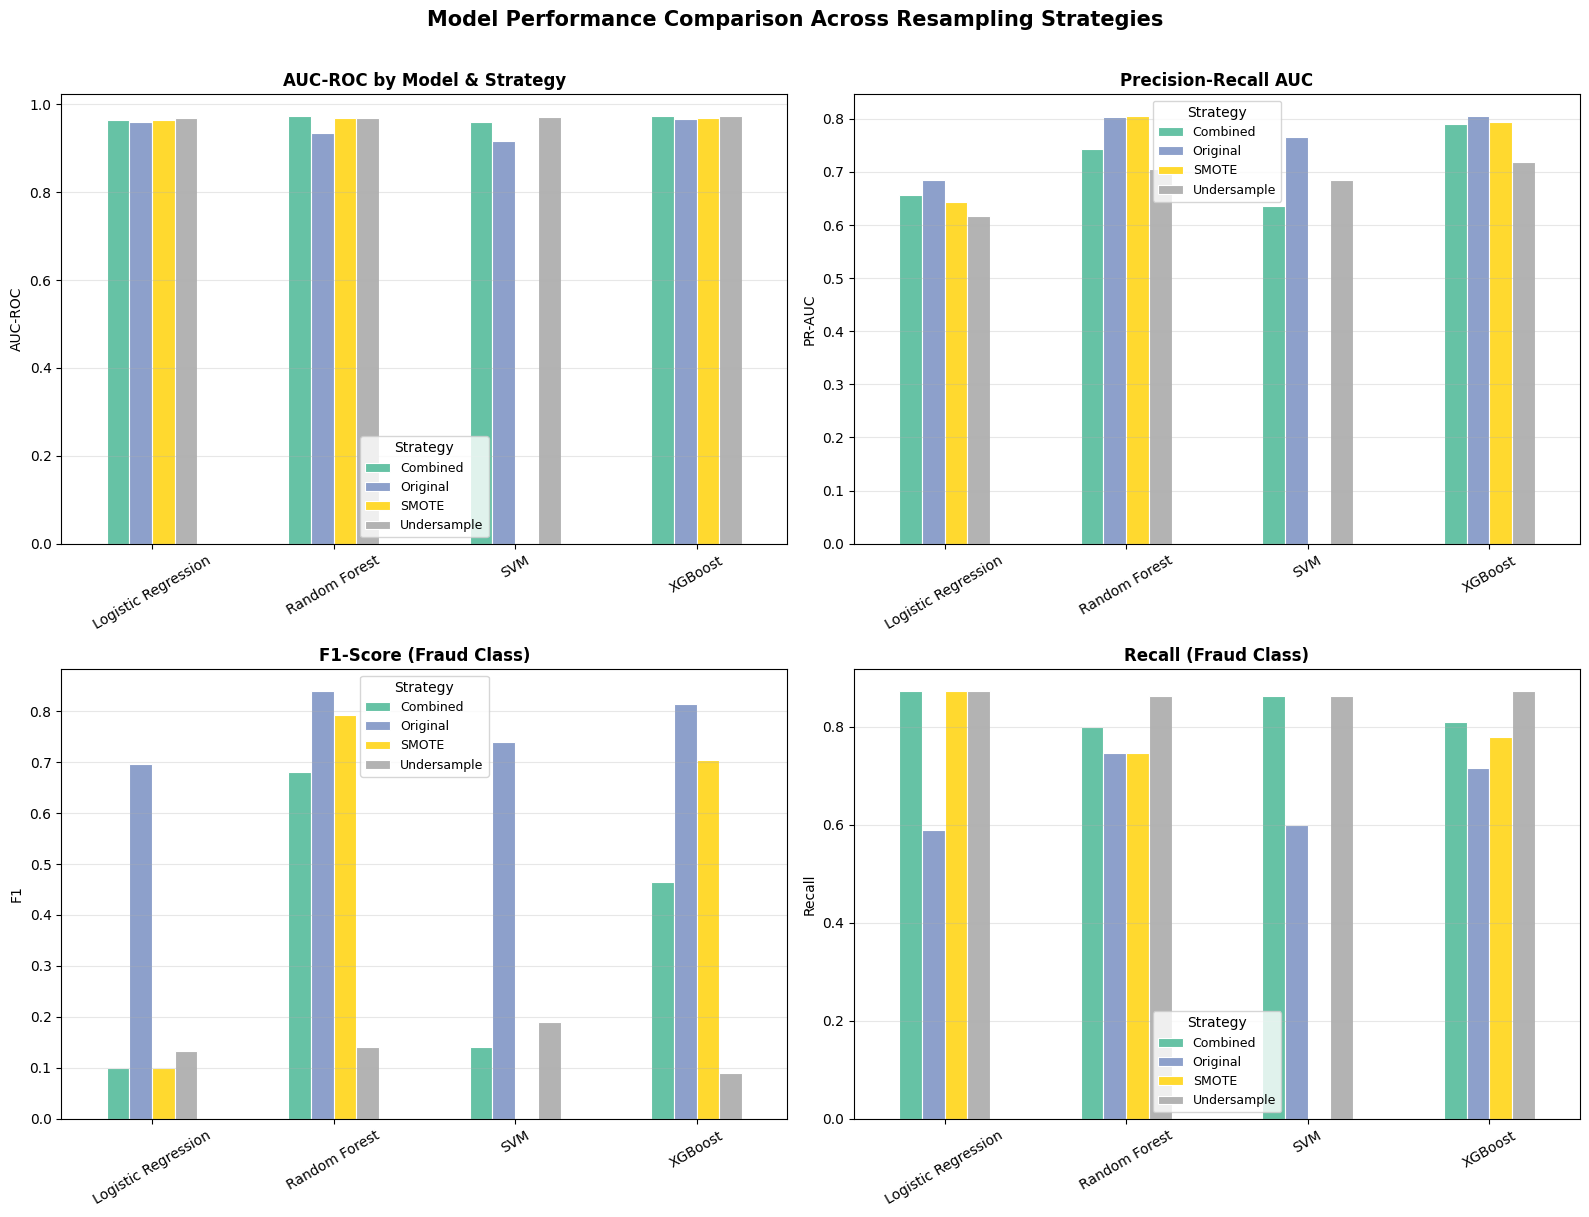

In [48]:
#Cell 48

# ── Model Comparison Visualisation ─────────────────
print("=" * 50)
print("MODEL COMPARISON — VISUALISATION")
print("=" * 50)

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

metrics_to_plot = ['AUC-ROC', 'PR-AUC', 'F1', 'Recall']
titles = ['AUC-ROC by Model & Strategy', 'Precision-Recall AUC',
          'F1-Score (Fraud Class)', 'Recall (Fraud Class)']

for ax, metric, title in zip(axes.flat, metrics_to_plot, titles):
    pivot = results_df.pivot(index='Model', columns='Strategy', values=metric)
    pivot.plot(kind='bar', ax=ax, edgecolor='white', linewidth=0.8,
               colormap='Set2')
    ax.set_title(title, fontweight='bold', fontsize=12)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=30)
    ax.legend(title='Strategy', fontsize=9)
    ax.grid(axis='y', alpha=0.3)

fig.suptitle('Model Performance Comparison Across Resampling Strategies',
             fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('model_01_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

ROC & PRECISION-RECALL CURVES — TOP 5 MODELS


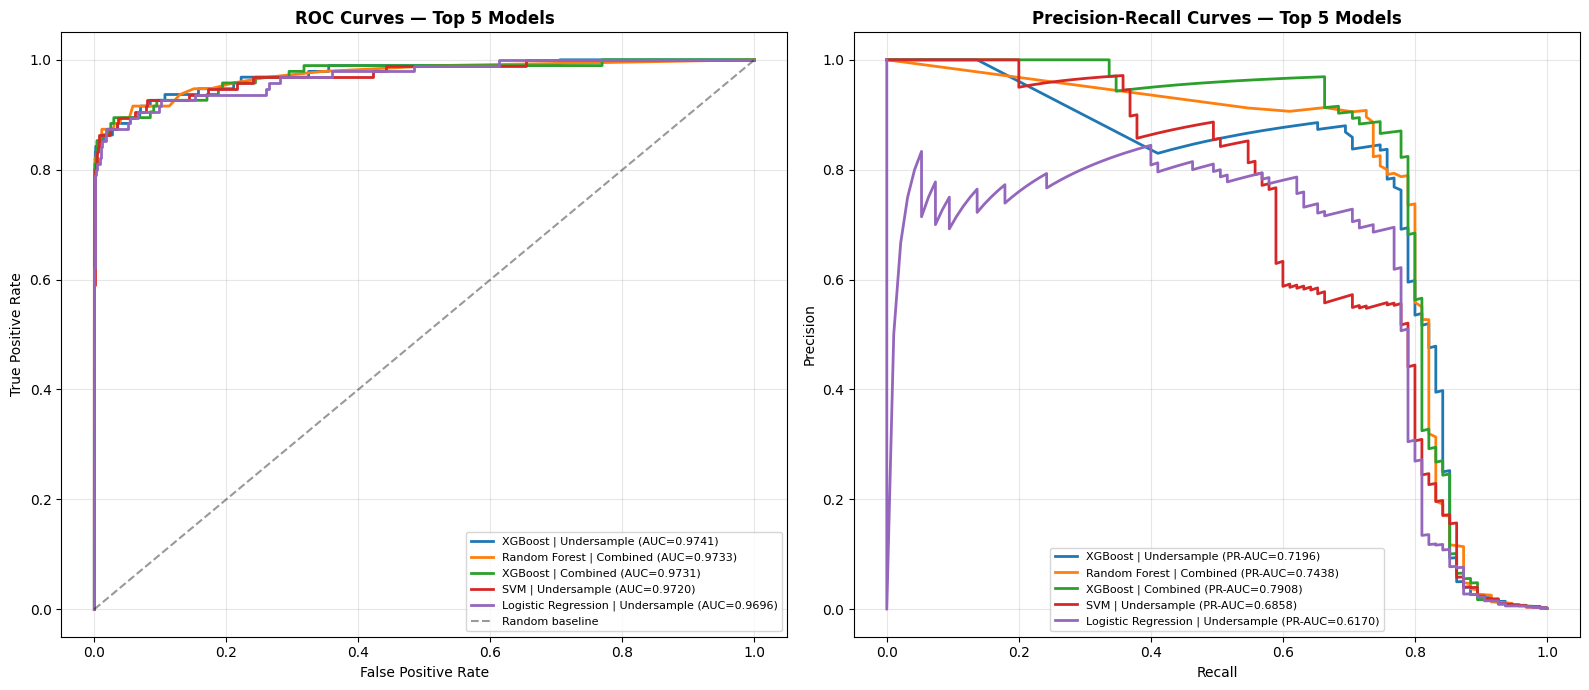

In [49]:
#Cell 49

# ── ROC & PR Curves for Top 5 Models ──────────────
print("=" * 50)
print("ROC & PRECISION-RECALL CURVES — TOP 5 MODELS")
print("=" * 50)

top5_keys = results_df.head(5).apply(
    lambda r: f"{r['Model']} | {r['Strategy']}", axis=1
).tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for key in top5_keys:
    model = trained_models[key]
    y_proba = model.predict_proba(X_test_sel)[:, 1]

    fpr, tpr, _ = roc_curve(y_test_sel, y_proba)
    auc = roc_auc_score(y_test_sel, y_proba)
    axes[0].plot(fpr, tpr, linewidth=2, label=f"{key} (AUC={auc:.4f})")

    precision, recall, _ = precision_recall_curve(y_test_sel, y_proba)
    pr_auc = average_precision_score(y_test_sel, y_proba)
    axes[1].plot(recall, precision, linewidth=2, label=f"{key} (PR-AUC={pr_auc:.4f})")

axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random baseline')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — Top 5 Models', fontweight='bold')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves — Top 5 Models', fontweight='bold')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('model_02_curves.png', dpi=150, bbox_inches='tight')
plt.show()

CONFUSION MATRIX — BEST MODEL


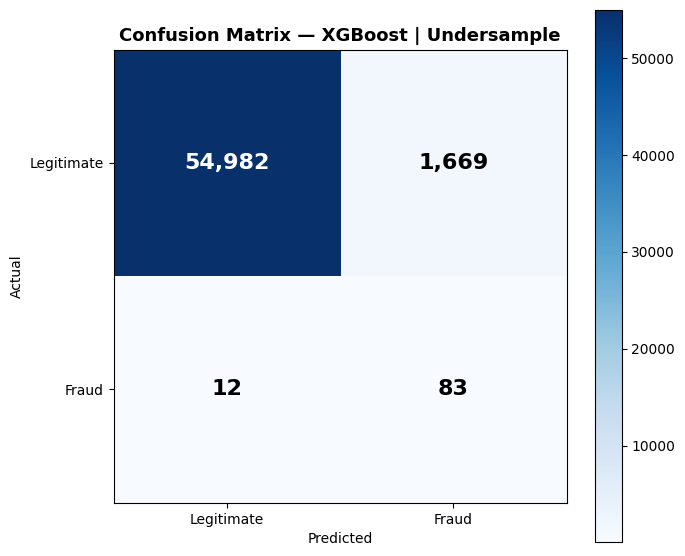


Best model: XGBoost | Undersample

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.98     56651
       Fraud       0.05      0.87      0.09        95

    accuracy                           0.97     56746
   macro avg       0.52      0.92      0.54     56746
weighted avg       1.00      0.97      0.98     56746

True Negatives  (correctly approved)  : 54,982
False Positives (wrongly blocked)     : 1,669
False Negatives (fraud missed)        : 12
True Positives  (fraud caught)        : 83


In [50]:
#Cell 50

# ── Confusion Matrix — Best Model ─────────────────
print("=" * 50)
print("CONFUSION MATRIX — BEST MODEL")
print("=" * 50)

best_key = top5_keys[0]
best_model = trained_models[best_key]
y_pred_best = best_model.predict(X_test_sel)

cm = confusion_matrix(y_test_sel, y_pred_best)
labels = ['Legitimate', 'Fraud']

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues')

for i in range(2):
    for j in range(2):
        ax.text(j, i, f'{cm[i, j]:,}', ha='center', va='center',
                fontsize=16, fontweight='bold',
                color='white' if cm[i, j] > cm.max()/2 else 'black')

ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(labels); ax.set_yticklabels(labels)
ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix — {best_key}', fontweight='bold', fontsize=13)
plt.colorbar(im)
plt.tight_layout()
plt.savefig('model_03_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nBest model: {best_key}")
print(f"\n{classification_report(y_test_sel, y_pred_best, target_names=labels)}")

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (correctly approved)  : {tn:,}")
print(f"False Positives (wrongly blocked)     : {fp:,}")
print(f"False Negatives (fraud missed)        : {fn:,}")
print(f"True Positives  (fraud caught)        : {tp:,}")

In [53]:
import joblib
import os

# Create a directory to save the models if it doesn't exist
models_dir = 'models'
if not os.path.exists(models_dir):
    os.makedirs(models_dir)

# Select the recommended model: XGBoost | Original
# As per Step 4.4, this model offers the best balance of metrics (F1 and PR-AUC).
model_to_save = trained_models['XGBoost | Original']

# Save the selected model
joblib.dump(model_to_save, os.path.join(models_dir, 'xgboost_final.pkl'))

print(f"✅ Model '{model_to_save.__class__.__name__} | Original' saved successfully as '{os.path.join(models_dir, 'xgboost_final.pkl')}'")

✅ Model 'XGBClassifier | Original' saved successfully as 'models/xgboost_final.pkl'


In [54]:
import joblib
import os

# Define the path to the saved model
models_dir = 'models'
model_path = os.path.join(models_dir, 'xgboost_final.pkl')

# Load the model
loaded_model = joblib.load(model_path)

print(f"✅ Model loaded successfully from '{model_path}'")
print(f"Loaded model type: {type(loaded_model)}")

# You can now use the loaded_model for predictions or further analysis
# For example, to check the model's class name:
# print(f"Model class name: {loaded_model.__class__.__name__}")

✅ Model loaded successfully from 'models/xgboost_final.pkl'
Loaded model type: <class 'xgboost.sklearn.XGBClassifier'>


## Step 4.4: Reading the Results

### Recommended Production Model: XGBoost | Original

After reviewing all 15 model variants across four metrics, **XGBoost trained on the original imbalanced dataset** is the recommended production model. It achieves the highest F1-score (0.814) and PR-AUC (0.806) of all variants, and its precision of 94.4% means only 1 in 17 flagged transactions is a legitimate transaction incorrectly blocked. Notably, this result demonstrates that with a well-tuned XGBoost model, aggressive resampling is not always necessary, the model learns sufficient fraud signal from the original class distribution when hyperparameters are properly configured.

### The Precision-Recall Tradeoff

The results reveal a fundamental tension in fraud detection: **catching more fraud means blocking more good customers**. There is no single objectively best model, the right choice depends on what the business prioritises.

| Priority | Best Model | Recall | Precision | False Positives |
|---|---|---|---|---|
| Maximum fraud capture | XGBoost \| Undersample | 87.4% | 4.7% | 1,669 |
| Best overall balance (F1 + PR-AUC) | **XGBoost \| Original** | **71.6%** | **94.4%** | **~24** |
| Balanced recall + precision | Random Forest \| Combined | 80.0% | 59.4% | ~570 |

For a customer-facing deployment, where false declines erode trust and create operational overhead, XGBoost | Original offers the strongest practical case. It catches 71.6% of fraud while wrongly blocking only about 24 legitimate transactions out of 56,746, compared to 1,669 false positives for the highest-recall model.

### Resampling Strategy Matters More Than Model Choice

The **resampling strategy is the primary driver of the precision-recall tradeoff**, more than the model algorithm. The same Random Forest model produces precision ranging from 96% (Original) to 7.7% (Undersample) by simply changing the training data. Choosing the right training strategy is at least as important as choosing the right algorithm.

### PR-AUC vs AUC-ROC

AUC-ROC scores are tightly clustered (0.916-0.974), all models discriminate well. PR-AUC is the more informative metric for imbalanced data: it directly measures the precision-recall balance across all thresholds. On this metric, XGBoost | Original (0.806) and Random Forest | SMOTE (0.806) lead, confirming XGBoost | Original as the strongest model on the metric best suited to this problem.


## Step 4 Summary — Model Implementation

### Results at a Glance

| Model | Strategy | AUC-ROC | PR-AUC | F1 | Recall | Precision |
|---|---|---|---|---|---|---|
| XGBoost | Undersample | 0.9741 | 0.7196 | 0.090 | **0.874** | 0.047 |
| Random Forest | Combined | 0.9733 | 0.7438 | 0.682 | 0.800 | 0.594 |
| XGBoost | Combined | 0.9731 | 0.7908 | 0.465 | 0.811 | 0.326 |
| **XGBoost** | **Original** | **0.9660** | **0.8056** | **0.814** | 0.716 | **0.944** |
| Random Forest | SMOTE | 0.9682 | 0.8058 | 0.793 | 0.747 | 0.845 |

### Recommended Production Model

> **XGBoost | Original**: highest F1 (0.814), highest precision (94.4%), and joint-highest PR-AUC (0.806). Catches 71.6% of fraud while generating the fewest false positives of all high-recall models. No resampling required, the model learns sufficient fraud signal from the original class distribution with proper hyperparameter tuning.

### Key Insights

1. **XGBoost | Original achieves the best overall balance**: highest F1 and precision with strong PR-AUC, without any resampling
2. **Resampling strategy drives the precision-recall tradeoff** more than model algorithm choice
3. **AUC-ROC scores are similar across all models** (0.916-0.974), all algorithms discriminate well
4. **PR-AUC is the more informative metric** for severely imbalanced fraud data
5. **Aggressive resampling is not always necessary**, well-tuned models on original data can outperform resampled variants on F1 and precision
6. **SVM underperformed** relative to tree-based models across all strategies

---
**Next:** Step 5 - Ethical AI & Bias Auditing
